# 7. Logistic Regression

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

So far, our focus has been on prediction engines, where the goal is to build models that predict a continuous response variable from one or more input features. These models minimize some form of squared error and aim to fit the best curve or surface to the data—an approach deeply rooted in continuous prediction.

But in many practical problems, we are not trying to predict a value; instead, we want to make a decision or assign a label. Will a system fail or not? Will a contaminant exceed a threshold? Will a storm cause flooding? These are classification problems, where the output is categorical rather than numerical.

## Readings/References

1. [Burkov, A. (2019) The One Hundred Page Machine Learning Book](http://ema.cri-info.cm/wp-content/uploads/2019/07/2019BurkovTheHundred-pageMachineLearning.pdf) Required Textbook

2. [Rashid, Tariq. (2016) Make Your Own Neural Network. Kindle Edition. ](https://www.goodreads.com/en/book/show/29746976-make-your-own-neural-network) Required Textbook

## Videos

## What is "Logistic Regression"?

Despite its name, logistic regression is not about regression in the traditional sense. Instead, it models the probability that a given input belongs to a particular class—usually coded as 0 or 1. It sits right on the boundary between regression and classification: we still estimate parameters by minimizing a loss function, but the target is a probability, and the ultimate goal is a binary decision.

- It bridges the familiar world of regression with the discrete nature of classification.
- It uses nonlinear transformation (the logistic or sigmoid function) to map predictions to probabilities.
- It lays the groundwork for more sophisticated classifiers, such as decision trees, support vector machines, and neural networks.

Civil engineers can use logistic regression to:
- Predict whether a hydraulic structure is likely to fail based on load and condition data,
- Classify storm events as safe or hazardous,
- And explore how decision boundaries emerge from simple parameter estimates.

Let’s begin by looking at the core idea: turning a linear model into a probability estimator.

## The Sigmoid Function: From Scores to Probabilities
At the heart of logistic regression is the sigmoid (or logistic) function:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$
 
This function takes any real-valued number $z$ and maps it to the interval $[0,1]$. In the context of logistic regression, $z$ is typically a linear combination of input variables:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots +\beta_n x_n $$
 
The sigmoid then transforms this linear score into a probability—interpreted as the likelihood of belonging to the positive class (usually labeled as 1).

### Python Code to Visualize the Sigmoid

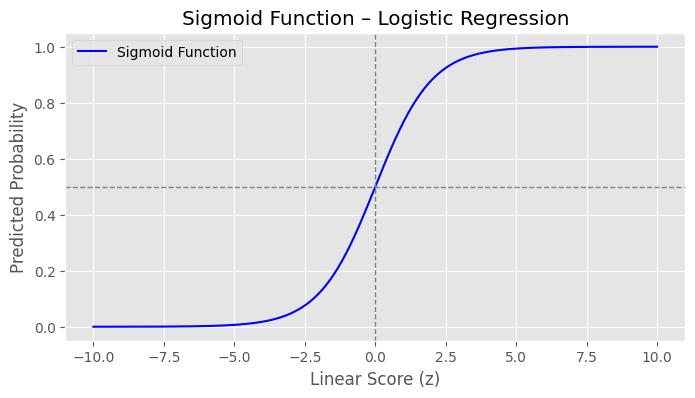

In [93]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values for z
z = np.linspace(-10, 10, 400)
prob = sigmoid(z)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(z, prob, label='Sigmoid Function', color='blue')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title("Sigmoid Function – Logistic Regression")
plt.xlabel("Linear Score (z)")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.legend()
plt.show()


## Simple Example: Logistic Model for System Failure

Let’s suppose you want to predict whether a system fails (1) or operates normally (0) based on a single variable: applied load.

We simulate some simple data below, then fit a logistic model.

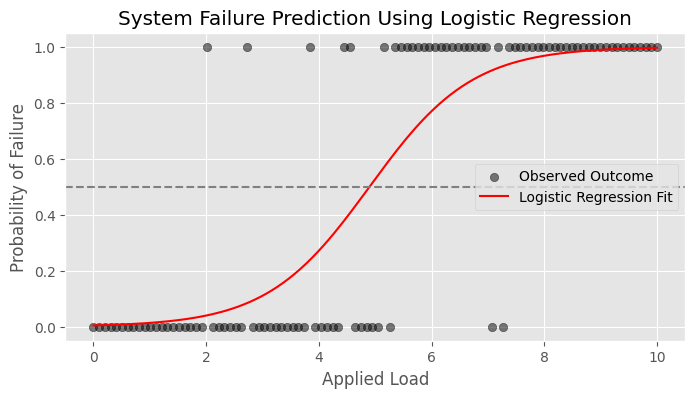

In [94]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Simulated data
np.random.seed(0)
load = np.linspace(0, 10, 100).reshape(-1, 1)
failure_prob = 1 / (1 + np.exp(-1.2 * (load - 5)))  # Centered around 5
failure = np.random.binomial(1, failure_prob.ravel())  # Simulate binary outcomes

# Fit logistic regression
model = LogisticRegression()
model.fit(load, failure)

# Predict probabilities
load_test = np.linspace(0, 10, 200).reshape(-1, 1)
predicted_prob = model.predict_proba(load_test)[:, 1]

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(load, failure, label='Observed Outcome', alpha=0.5, color='black')
plt.plot(load_test, predicted_prob, label='Logistic Regression Fit', color='red')
plt.axhline(0.5, linestyle='--', color='gray')
plt.title("System Failure Prediction Using Logistic Regression")
plt.xlabel("Applied Load")
plt.ylabel("Probability of Failure")
plt.legend()
plt.grid(True)
plt.show()


# 7.1 A Logistic Regression Example

Logistic regression is a type of model fitting exercise where the **observed** responses are binary encoded (0,1).  The input design matrix is a collection of features much like ordinary linear regression. 

The logistic function is 

$$\pi_i(\beta) = \frac{e^{X_i~\beta}}{1+e^{X_i~\beta}} $$

where $X_i$ is the i-th row of the design matrix, and $\beta$ are unknown coefficients.

The associated optimization problem is to minimize some measure of error between the model values (above) and the observed values, typically a squared error is considered.

If we consider a single observatyon $Y_i$ its value is either 0 or 1.  So the error is

$$\epsilon_i = Y_i - \pi_i(\beta) = Y_i - \frac{e^{X_i~\beta}}{1+e^{X_i~\beta}} $$

The function we wish to minimize is 

$$\min_{\beta} (Y - \pi(\beta))^T(Y-\pi(\beta))$$

The minimization method is a matter of analyst preference - these are usually well behaved minimization problems (the examples will use [Powell's Direction Set Method](https://en.wikipedia.org/wiki/Powell%27s_method), and the [Broyden–Fletcher–Goldfarb–Shanno](https://machinelearningmastery.com/bfgs-optimization-in-python/) algorithm; most professional tools operate on the logarithm of the components to avoid numerical overflow during the minimization process.  

:::{note}
Powell's method is robust and comparatively simple to program, here is some older code [Powell's Method FORTRAN source code](https://github.com/dustykat/powell-search-tool) that is fairly readable and still works today!
:::

The model result $\pi_i$ will range between 0 and 1, and can be interpreted as a probability that the inputs predict a value of 1.  Normally the decision boundary is set at 0.5, so when the model is cast into a prediction engine it will first compute a $\pi_i$ value, then apply the decision boundary rule to either snap the result to 1 or 0 as indicated by the probability.  

The example below should help clarify a bit.

## Success at Task vs Experience 

A systems analyst studied the effect of experience on ability to complete a complex task within a specified time.
The participants had varying amounts of experience measured in months as shown in the table below, where E represents months of experience, and S is binary 0=FAIL, 1=SUCCESS

```
 E  S
14  0  
29  0  
 6  0  
25  1  
18  1  
 4  0  
18  0  
12  0  
22  1  
 6  0  
30  1  
11  0  
30  1  
 5  0  
20  1  
13  0  
 9  0  
32  1  
24  0  
13  1  
19  0  
 4  0  
28  1  
22  1  
 8  1  
```

Perform a logistic regression and estimate the experience required to ensure sucess with an empirical probability of 75 percent.

In [95]:
%reset -f
# Load the data
experience=[14,29,6,25,18,4,18,12,22,6,30,11,30,5,20,13,9,32,24,13,19,4,28,22,8]
result=[0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,1,1,1]

Now lets plot the data and see what we can learn, later on we will need a model and data plot on same figure, so just build it here

In [96]:
# Load a Plotting Tool
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

Now plot the data

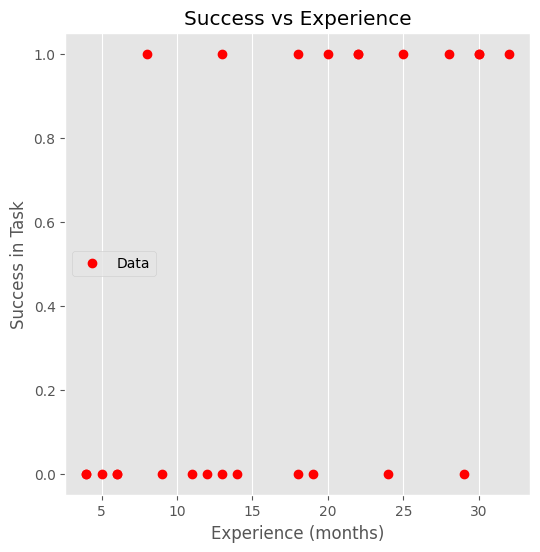

In [97]:
make1plot(experience,result,"Experience (months)","Success in Task","Success vs Experience")

Now a logistic model, we will need 3 prototype functions; a sigmoid function, an error function (here we use sum of squared error) and a merit function to minimize by changing $\beta_0$ and $\beta_1$.

The sigmoid function is

$$\pi_i = \frac{e^{\beta_0 + \beta_1 X_i}}{1+e^{\beta_0 + \beta_1 X_i}} $$


In [98]:
def pii(b0,b1,x): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x)/(1+ math.exp(b0+b1*x))
    return(pii)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global result,experience #access lists already defined external to function
    mod=[0 for i in range(len(experience))]
    for i in range(len(experience)):
        mod[i]=pii(beta[0],beta[1],experience[i])
    merit = sse(mod,result)
    return(merit)

Now we will attempt to minimize the merit function by changing values of $\beta$, first lets apply an initial value and check that our merit function works

In [99]:
beta = [0,0] #initial guess of betas
merit(beta) #check that does not raise an exception

6.25

Good we obtained a value, and not an error, now an optimizer

In [100]:
import numpy as np
from scipy.optimize import minimize

#x0 = np.array([-3.0597,0.1615])
x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True})

Optimization terminated successfully.
         Current function value: 4.199713
         Iterations: 5
         Function evaluations: 132


Yay! It found some answer, examine and plot the findings

 b0 =  -2.982390266878914
 b1 =  0.15954743797099522


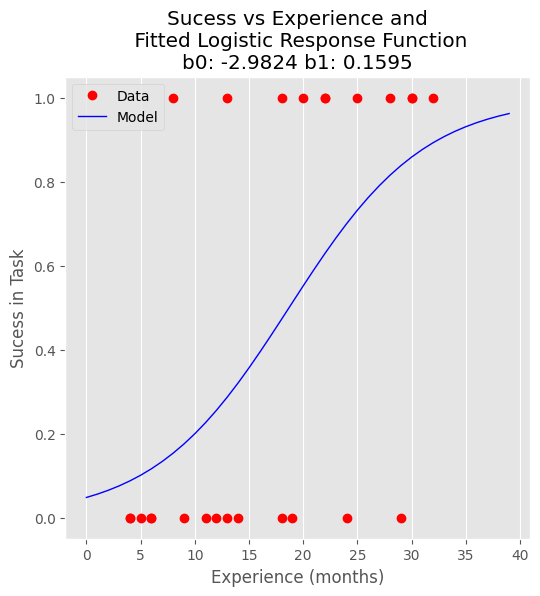

In [101]:
fitted=[0 for i in range(40)]
xaxis =[0 for i in range(40)]
beta[0]=res.x[0]
beta[1]=res.x[1]
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

Now to recover estimates of success for different experience levels

In [102]:
guess = 25.5
pii(res.x[0],res.x[1],guess)

0.7476408418994896

So we expect that someone with 25 to 26 months of experience would have a 75 percent chance of success.  Similarily the time to median success is 18 months and 3 weeks.

In [103]:
guess = 18.75
pii(res.x[0],res.x[1],guess)

0.5022810329444896

Now using the same data, but a formal logistic package

In [104]:
# import the class
import numpy
from sklearn.linear_model import LogisticRegression
X = numpy.array(experience)
y = numpy.array(result)
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000);
# fit the model with data  -TRAIN the model
logreg.fit(X.reshape(-1, 1),y);

In [105]:
logreg.coef_

array([[0.16080665]])

In [106]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(xplot.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]



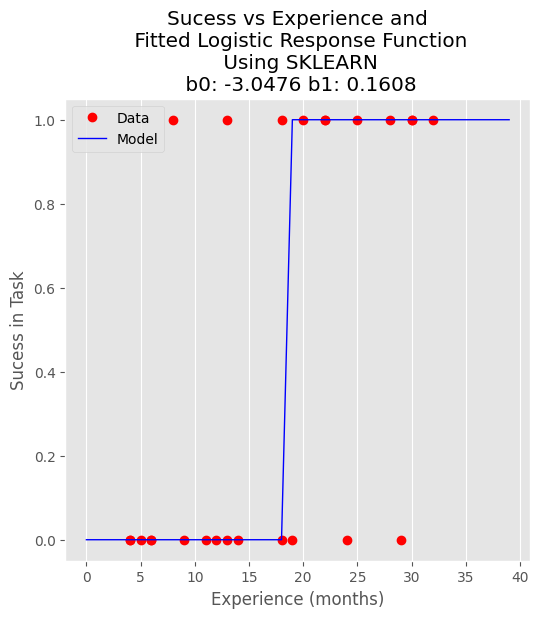

In [107]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(experience,result,xplot,y_pred,'Experience (months)','Sucess in Task',plottitle)

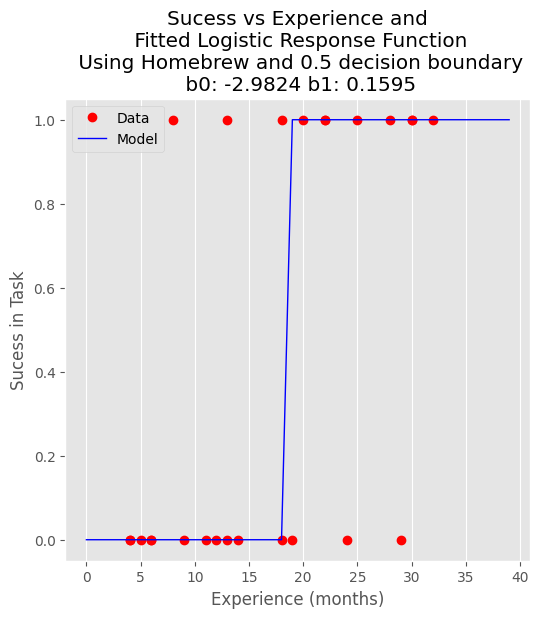

In [108]:
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(beta[0],beta[1],float(i))
#    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using Homebrew and 0.5 decision boundary\n '+'b0: '+ str(round(beta[0],4)) + ' b1: ' + str(round(beta[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

A proper ML approach would create a hold-out set (split) to provide some test of the model - in this example the data set is too small but to explore the syntax using ML workflow ....

### Split the Data Set

In [109]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

Now perform the ML execrise in typical workflow

In [110]:
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000);
# fit the model with data  -TRAIN the model
logreg.fit(X_train.reshape(-1, 1),y_train);

In [111]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(X_test.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]

for i in range(40):
    xaxis[i]=float(i)
#    fitted[i]=pii(beta[0],beta[1],float(i))
    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

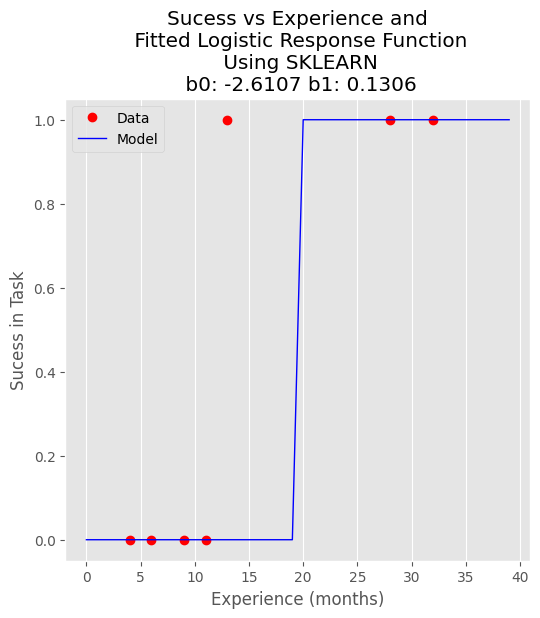

In [112]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(X_test,y_test,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

### How to assess the performance of logistic regression?

> Binary classification has four possible types of results:
>- True negatives: correctly predicted negatives (zeros)
>- True positives: correctly predicted positives (ones)
>- False negatives: incorrectly predicted negatives (zeros)
>- False positives: incorrectly predicted positives (ones)
    
We usually evaluate the performance of a classifier by comparing the actual and predicted outputs and counting the correct and incorrect predictions.  Our simple graph above conveys the same information, just not as easily interpreted. 

A confusion matrix is a table that is used to display the performance of a classification model. 
    
<br> ![](https://image.jimcdn.com/app/cms/image/transf/dimension=699x10000:format=png/path/s8ff3310143614e07/image/iab2d53abc26a2bc7/version/1549760945/image.png) <br>

Some other indicators of binary classifiers include the following:
- The most straightforward indicator of classification accuracy is the ratio of the number of correct predictions to the total number of predictions (or observations). 
- The positive predictive value is the ratio of the number of true positives to the sum of the numbers of true and false positives.
- The negative predictive value is the ratio of the number of true negatives to the sum of the numbers of true and false negatives.
- The sensitivity (also known as recall or true positive rate) is the ratio of the number of true positives to the number of actual positives.
- The precision score quantifies the ability of a classifier to not label a negative example as positive. The precision score can be interpreted as the probability that a positive prediction made by the classifier is positive.
- The specificity (or true negative rate) is the ratio of the number of true negatives to the number of actual negatives. 
<br>    ![](https://miro.medium.com/max/936/0*R7idSv1bja3CLC8s.png) <br>
    
The extent of importance of recall and precision depends on the problem. Achieving a high recall is more important than getting a high precision in cases like when we would like to detect as many heart patients as possible. For some other models, like classifying whether a bank customer is a loan defaulter or not, it is desirable to have a high precision since the bank wouldn’t want to lose customers who were denied a loan based on the model’s prediction that they would be defaulters. 
There are also a lot of situations where both precision and recall are equally important. Then we would aim for not only a high recall but a high precision as well. In such cases, we use something called F1-score. F1-score is the Harmonic mean of the Precision and Recall: 
<br> ![](https://cdn.analyticsvidhya.com/wp-content/uploads/2019/09/f1score-300x73.png) <br>
This is easier to work with since now, instead of balancing precision and recall, we can just aim for a good F1-score and that would be indicative of a good Precision and a good Recall value as well.
<br>    ![](https://memegenerator.net/img/instances/85090403.jpg) <br>
### Model Evaluation using Confusion Matrix

The confusion matrix is a table that is used to evaluate the performance of a classification model. You can also visualize the performance of an algorithm. The fundamental content of a confusion matrix is the number of correct and incorrect predictions are summed up class-wise.

In [113]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix

array([[4, 1],
       [0, 2]])

However it is often more visible in a heatmap structure

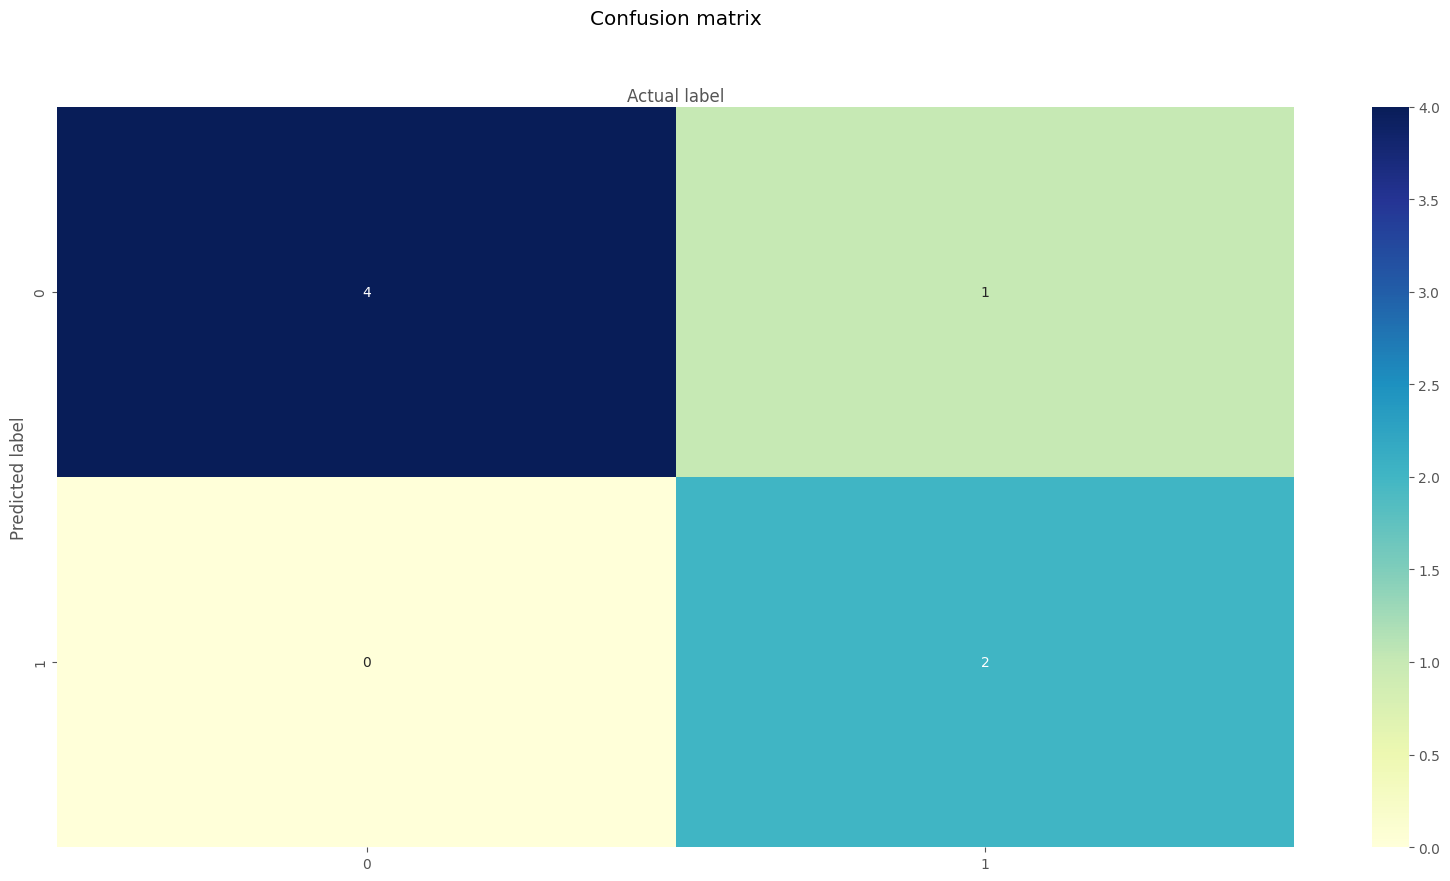

In [114]:
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

Confusion Matrix Evaluation Metrics: evaluate the model using model evaluation metrics such as accuracy, precision, and recall. Its all built-in to sklearn (although we could get it entirely from our homebrew results too!)

In [115]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1-score:",metrics.f1_score(y_test, y_pred))

Accuracy: 0.8571428571428571
Precision: 1.0
Recall: 0.6666666666666666
F1-score: 0.8


In [116]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



# 7.2 Selecting the Decision Boundary

In practice, the decision boundary for logistic regression is commonly set at 0.5, reflecting the point where the model's estimated probability of success equals that of failure.

However, this threshold is not fixed. It may be lowered to increase sensitivity (e.g., in public health to catch more positives), or raised to improve specificity (e.g., in fraud detection to reduce false positives).

Thresholds should reflect the relative cost of misclassification, the balance of class frequencies, or policy objectives — and may be determined through ROC analysis, Precision-Recall tradeoffs, or domain knowledge.

## Some references

1. [Hastie, Tibshirani, Friedman (2009) The Elements of Statistical Learning ](https://hastie.su.domains/ElemStatLearn/) Chapter 4.4: "Two-Class Logistic Regression" ... “the class label is typically assigned based on whether the estimated probability exceeds 0.5. However, if the costs of misclassification are asymmetric, this threshold can be adjusted accordingly.”
2. [James, Witten, Hastie, Tibshirani (2013) An Introduction to Statistical Learning](https://www.statlearning.com/) Chapter 4.3: "Logistic Regression" ... “If we are interested in the most accurate predictions, then the default threshold of 0.5 is often reasonable. But if false positives or false negatives are more costly, then the threshold should be modified.”
3. [Christopher Bishop (2006) Pattern Recognition and Machine Learning]() Chapter 4: "Linear Models for Classification" Discusses decision boundaries in probabilistic terms, and introduces the idea that thresholds may vary based on prior class probabilities or expected costs of errors.
4. [sklearn.linear_model.LogisticRegression](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html) guide Recommends using ROC curves or Precision-Recall analysis to set thresholds based on context, particularly for imbalanced datasets.

:::{tip}
The 0.5 threshold is standard in binary logistic regression, it's not a rigid or universal rule. The threshold used to define the decision boundary can and often should be adjusted based on:
- Class imbalance
- Cost of false positives vs false negatives
- Risk preferences or operating context
- ROC or Precision-Recall trade-offs
:::

:::{note}
Below is a modularized version generated by Chat GPT, using usual principles of AI-assisted code generation.

The actual prompt is

"Here's my logistic example, can you examine and modularize my code.  I want to maintain my multiple cell structure for teaching pace"
:::

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [118]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def make1plot(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


In [119]:
# Simulate experience (months) and probability of success
np.random.seed(42)
experience = np.linspace(0, 12, 50).reshape(-1, 1)
true_params = [0.8, -4.5]
logit_score = true_params[0] * experience + true_params[1]
prob_success = sigmoid(logit_score)
result = np.random.binomial(1, prob_success.ravel())  # Binary outcome


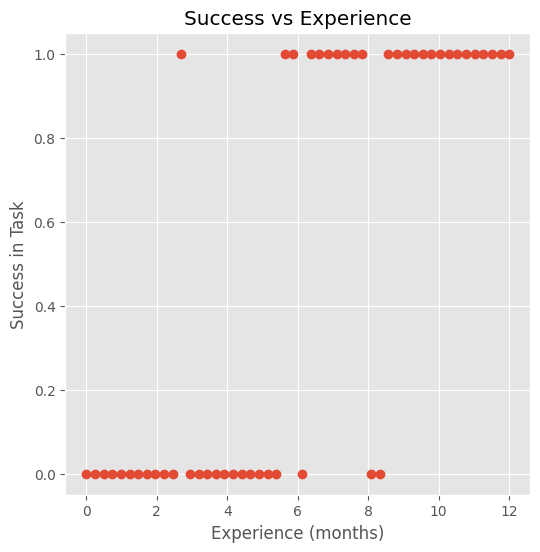

In [120]:
make1plot(experience, result, "Experience (months)", "Success in Task", "Success vs Experience")


In [121]:
model = LogisticRegression()
model.fit(experience, result)

# Predict probability over a finer grid
x_pred = np.linspace(0, 12, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]


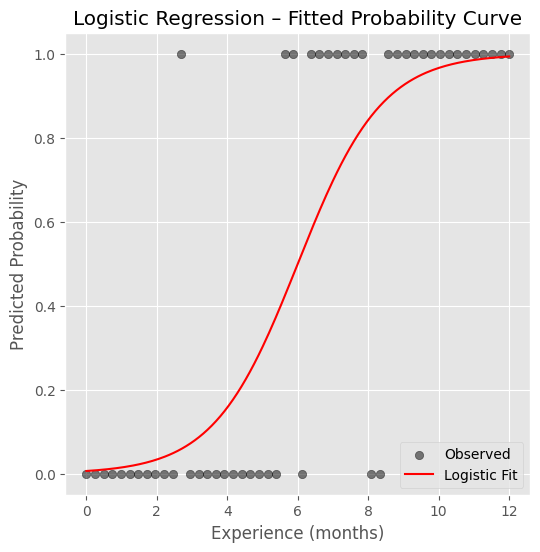

In [122]:
plt.figure(figsize=(6, 6))
plt.scatter(experience, result, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Experience (months)")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression – Fitted Probability Curve")
plt.legend()
plt.grid(True)
plt.show()


In [123]:
y_pred_binary = model.predict(experience)
print(confusion_matrix(result, y_pred_binary))
print(classification_report(result, y_pred_binary))


[[22  3]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        25
           1       0.88      0.88      0.88        25

    accuracy                           0.88        50
   macro avg       0.88      0.88      0.88        50
weighted avg       0.88      0.88      0.88        50



# 7.3 Logistic Regression in Designed Experiments

Logistic regression is a powerful tool for analyzing structured experiments, especially when the outcomes are expressed as proportions. These situations often arise in marketing studies, medical trials, and other behavioral or economic experiments. 

For instance, suppose we send out 1,000 surveys and receive 300 responses. While each individual response is binary (responded or not), we're often more interested in the *proportion* of responses in each category or treatment level. In such cases, we compute the observed proportion as:

$$ p_j = \frac{R_j}{n_j} $$

where:
- $ p_j $ is the observed proportion of responses in treatment level $ j $,
- $ R_j $ is the number of positive (1-valued) responses, and
- $ n_j $ is the total number of observations in that treatment level.

We then model these proportions using the logistic (sigmoid) transformation:

$$ \pi_j(\beta) = \frac{e^{X_j \beta}}{1 + e^{X_j \beta}} $$

The residual error is:

$$ \epsilon_j = p_j - \pi_j(\beta) $$

and the objective function to minimize becomes:

$$ \min_{\beta} \left( \vec{p} - \pi(\beta) \right)^T \left( \vec{p} - \pi(\beta) \right) $$

The example below illustrates this approach using synthetic data from a coupon redemption study.


## Redemption Rate vs. Rebate Value

Consider a marketing study designed to estimate how the value of a coupon rebate affects the likelihood of customer redemption. In this experiment, 1,000 participants were randomly selected and each received a coupon along with advertising material. The coupons offered different rebate values—specifically, \$5, \$10, \$15, \$20, and \$30. Each rebate level was assigned to 200 participants.

The key variables in this study are:
- **Predictor**: Coupon rebate value (\$)
- **Response**: Number of coupons redeemed in each group

The data are summarized in the following table:

| Level $ j $ | Price Reduction $ X_j $ | Participants $ n_j $ | Redeemed $ R_j $ |
|--------------:|--------------------------:|------------------------:|-------------------:|
| 1             | 5                         | 200                    | 30                |
| 2             | 10                        | 200                    | 55                |
| 3             | 15                        | 200                    | 70                |
| 4             | 20                        | 200                    | 100               |
| 5             | 30                        | 200                    | 137               |

As with any modeling task, we begin by preparing the dataset, computing the proportion of redemptions at each level, and visualizing the relationship between the rebate and redemption rate.


In [124]:
%reset -f
# Load The Data
level = [1,2,3,4,5]
reduction = [5,10,15,20,30]
participants = [200,200,200,200,200]
redeemed = [30,55,70,100,137]
proportion = [0 for i in range(len(level))]
for i in range(len(proportion)):
    proportion[i]=redeemed[i]/participants[i]

Next, we perform some basic exploratory data analysis. Since we only have one predictor (rebate value) and a proportion response, a simple scatter plot will suffice to help us visualize the relationship.

This initial step helps us answer: is there a clear trend? Does a larger rebate lead to more redemptions?

In [125]:
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='v',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.grid(which='both',axis='both')
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

%matplotlib inline

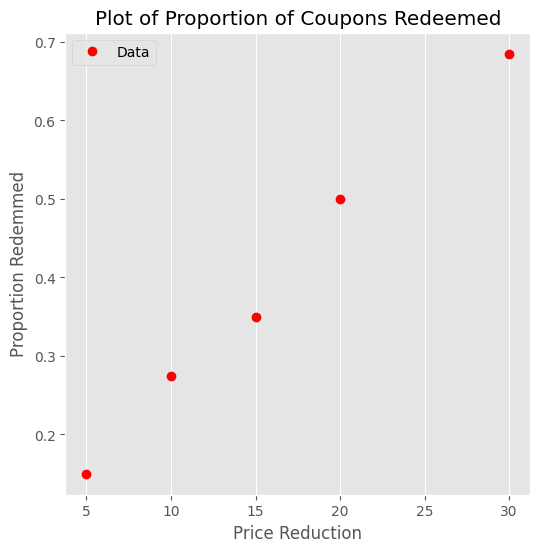

In [126]:
make1plot(reduction,proportion,'Price Reduction','Proportion Redemmed','Plot of Proportion of Coupons Redeemed')

From the plot, we observe a clear trend: as the rebate value increases, the proportion of coupons redeemed also increases. This aligns with our intuition—higher incentives generally lead to greater participation.

But what if we want to estimate redemption rates for rebate values that weren't tested, or optimize the rebate amount to achieve a target redemption rate? For these tasks, logistic regression offers a smooth predictive curve over the entire domain, even between and beyond the sampled rebate values.

We now define our logistic regression functions—reusing the structure from a previous example, but adapting the variable names to fit the context of this marketing study.


In [127]:
def pii(b0,b1,x): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x)/(1+ math.exp(b0+b1*x))
    return(pii)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global proportion,reduction #access lists already defined external to function
    mod=[0 for i in range(len(proportion))]
    for i in range(len(level)):
        mod[i]=pii(beta[0],beta[1],reduction[i])
    merit = sse(mod,proportion)
    return(merit)


We make an initial guess for the regression coefficients and evaluate the merit function. This helps us understand the behavior of the model before full optimization.


In [128]:
beta = [0,0] # initial guess
merit(beta) # test for exceptions

0.22985

We now fit the model using Powell’s method, a derivative-free optimization algorithm suitable for this kind of nonlinear objective function.


Optimization terminated successfully.
         Current function value: 0.002032
         Iterations: 3
         Function evaluations: 81
 b0 =  -2.0165402749739756
 b1 =  0.09580373659184761


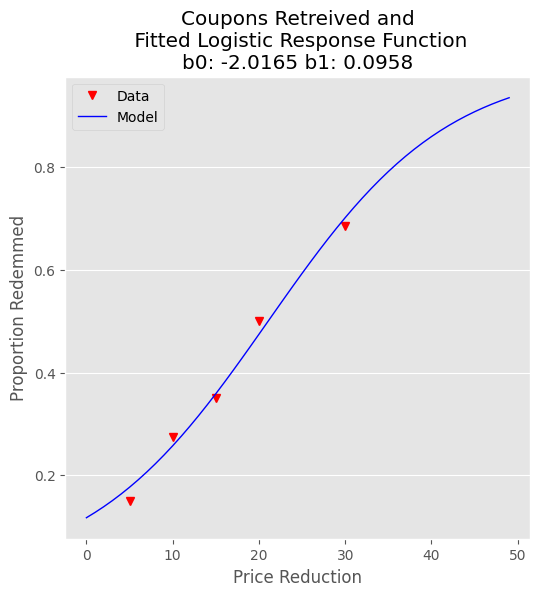

In [129]:
import numpy as np
from scipy.optimize import minimize

x0 = np.array([-2,0.09])
res = minimize(merit, x0, method='powell',options={'disp': True})
# 
fitted=[0 for i in range(50)]
xaxis =[0 for i in range(50)]
for i in range(50):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])

plottitle = 'Coupons Retreived and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(reduction,proportion,xaxis,fitted,'Price Reduction','Proportion Redemmed',plottitle)

With the model fit, we can ask practical questions: What rebate value corresponds to a 50% redemption rate? This is equivalent to finding the decision boundary of our logistic model.


In [130]:
guess = 21.05
fraction = pii(res.x[0],res.x[1],guess)
print("For Reduction of ",guess," projected redemption rate is ",round(fraction,3))

For Reduction of  21.05  projected redemption rate is  0.5


For more aggressive marketing goals—such as liquidating excess inventory—we might ask: what rebate value is needed to push redemption to 98%?


In [131]:
guess = 61.90
fraction = pii(res.x[0],res.x[1],guess)
print("For Reduction of ",guess," projected redemption rate is ",round(fraction,3))

For Reduction of  61.9  projected redemption rate is  0.98


To communicate our results to non-technical stakeholders, we generate a plot showing the fitted logistic curve and the observed redemption rates. This visualization helps reinforce trust in the model's predictions.


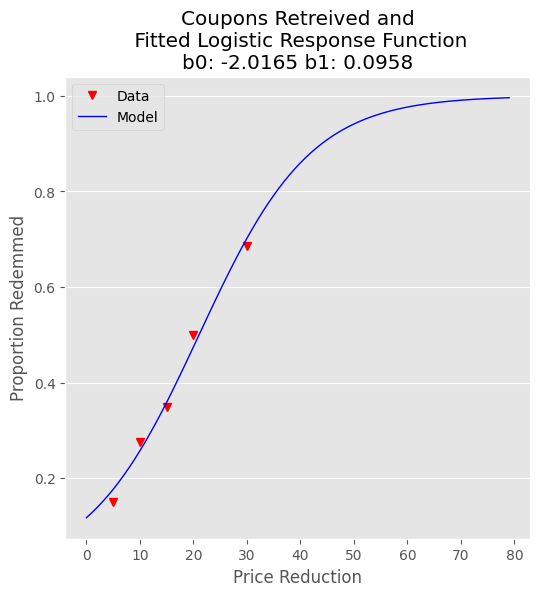

In [132]:
fitted=[0 for i in range(80)]
xaxis =[0 for i in range(80)]
for i in range(80):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))

plottitle = 'Coupons Retreived and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(reduction,proportion,xaxis,fitted,'Price Reduction','Proportion Redemmed',plottitle)

## Exercises
1. Use the model to estimate redemption rate for a \$25 rebate.
2. Modify the number of participants per level and re-run the model. How sensitive are predictions to sample size?
3. Suppose we cap the rebate budget at \$1,500 for the entire group. Can you propose an optimal allocation across price levels?

## References
1. [Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression*. Wiley.](https://dl.icdst.org/pdfs/files4/7751d268eb7358d3ca5bd88968d9227a.pdf)
   <!--[Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression*. Wiley. (local copy)](http://54.243.252.9/ce-5319-webroot/3-Readings/7751d268eb7358d3ca5bd88968d9227a.pdf)-->
3. [McCullagh, P., & Nelder, J. A. (1989). *Generalized Linear Models*. Chapman & Hall.](https://www.utstat.toronto.edu/brunner/oldclass/2201s11/readings/glmbook.pdf)
   <!--[McCullagh, P., & Nelder, J. A. (1989). *Generalized Linear Models*. Chapman & Hall. (local copy)](http://54.243.252.9/ce-5319-webroot/3-Readings/glmbook.pdf)-->
5. [StatsModels Documentation](https://www.statsmodels.org/)



   Rebate  Participants  Redeemed  Proportion
0       5           201        37    0.184080
1      10           242        81    0.334711
2      15           164        71    0.432927
3      20           221       145    0.656109
4      30           210       175    0.833333


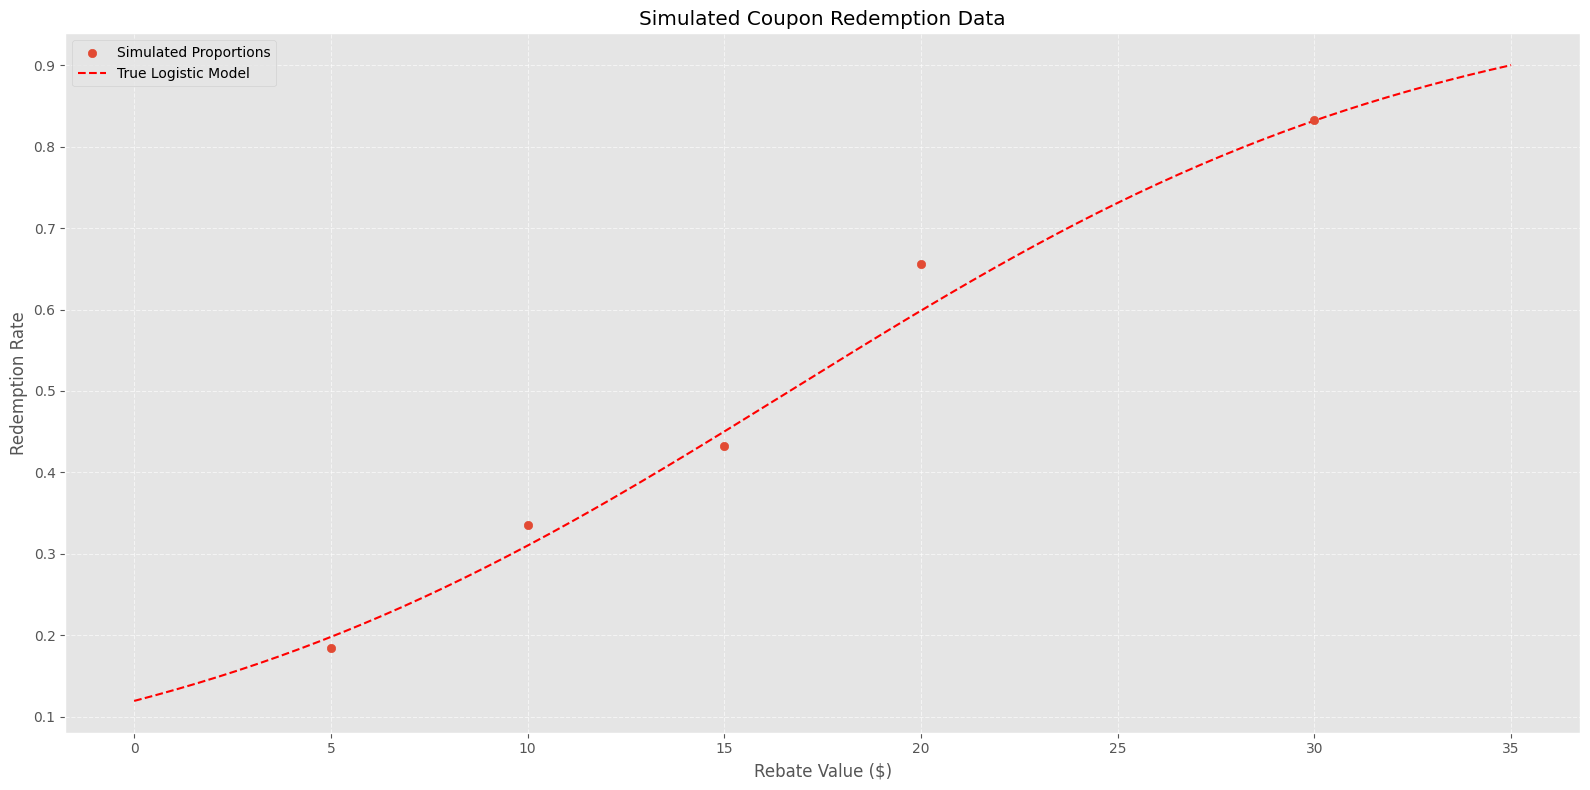

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for repeatability
np.random.seed(42)

# Define rebate levels (predictor values)
rebate_levels = np.array([5, 10, 15, 20, 30])

# Randomize number of participants per level (e.g., between 150 and 250)
participants_per_level = np.random.randint(150, 250, size=len(rebate_levels))

# Define true logistic model parameters for simulation
true_intercept = -2.0
true_slope = 0.12

# Compute true probability of redemption at each level
def logistic(x, b0=true_intercept, b1=true_slope):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

true_probs = logistic(rebate_levels)

# Simulate number of redemptions as binomial draws
redemptions = np.random.binomial(participants_per_level, true_probs)

# Assemble the simulated dataset
simulated_data = pd.DataFrame({
    'Rebate': rebate_levels,
    'Participants': participants_per_level,
    'Redeemed': redemptions,
    'Proportion': redemptions / participants_per_level
})

# Show the dataset
print(simulated_data)

# Optional: plot the simulated proportions and true logistic curve
x_plot = np.linspace(0, 35, 200)
plt.scatter(rebate_levels, simulated_data['Proportion'], label='Simulated Proportions', zorder=3)
plt.plot(x_plot, logistic(x_plot), 'r--', label='True Logistic Model')
plt.xlabel('Rebate Value ($)')
plt.ylabel('Redemption Rate')
plt.title('Simulated Coupon Redemption Data')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


   Rebate  Intercept  Participants  Redeemed  Proportion
0       5     -1.544           216        58    0.268519
1      10     -2.014           242        84    0.347107
2      15     -1.521           248       140    0.564516
3      20     -2.535           167        80    0.479042
4      30     -2.086           233       185    0.793991


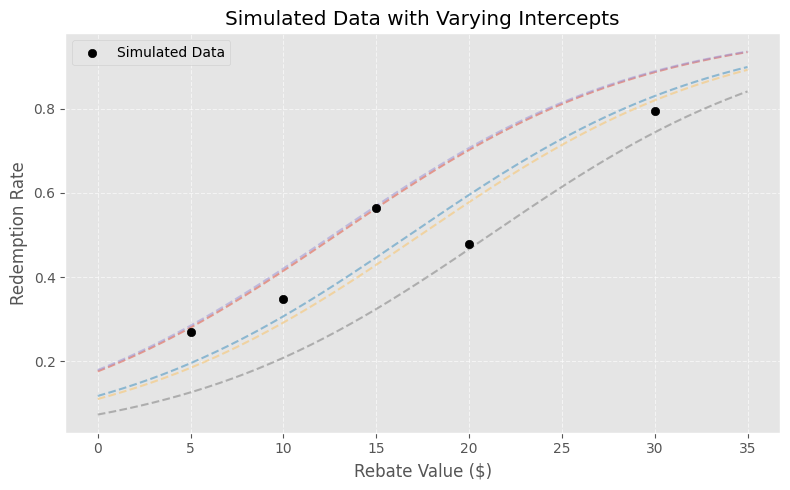

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(123)

# Define rebate levels (predictor values)
rebate_levels = np.array([5, 10, 15, 20, 30])

# Randomize number of participants per level
participants_per_level = np.random.randint(150, 251, size=len(rebate_levels))

# Base logistic model slope (kept fixed)
true_slope = 0.12

# Define intercepts that vary by rebate level
# (e.g., due to regional or marketing channel effects)
base_intercept = -2.0
intercept_variation = np.random.normal(loc=0, scale=0.3, size=len(rebate_levels))
varying_intercepts = base_intercept + intercept_variation

# Define logistic function with per-level intercepts
def logistic(x, b0, b1=true_slope):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

# Compute probabilities and simulate redemptions
true_probs = [logistic(x, b0) for x, b0 in zip(rebate_levels, varying_intercepts)]
redemptions = np.random.binomial(participants_per_level, true_probs)

# Assemble dataset
simulated_data = pd.DataFrame({
    'Rebate': rebate_levels,
    'Intercept': np.round(varying_intercepts, 3),
    'Participants': participants_per_level,
    'Redeemed': redemptions,
    'Proportion': redemptions / participants_per_level
})

# Display the simulated data
print(simulated_data)

# Plot: Simulated data points and multiple logistic curves
x_plot = np.linspace(0, 35, 300)
plt.figure(figsize=(8, 5))

# Plot each individual curve
for i, (b0, label) in enumerate(zip(varying_intercepts, rebate_levels)):
    plt.plot(x_plot, logistic(x_plot, b0), linestyle='--', alpha=0.5)

# Overlay simulated points
plt.scatter(rebate_levels, simulated_data['Proportion'], color='black', label='Simulated Data', zorder=5)
plt.xlabel('Rebate Value ($)')
plt.ylabel('Redemption Rate')
plt.title('Simulated Data with Varying Intercepts')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# 7.4 Multiple Logistic Regression

Simple logistic regression can be extended to handle multiple predictors by expanding the definition of the design matrix $ X $ and the coefficient vector $ \beta $, just as we did in linear regression.

This approach allows us to explore more complex relationships where the probability of a binary outcome depends on multiple features.

## Disease Rate vs Multiple Predictors

In this illustrative example, researchers investigate the outbreak of a mosquito-borne illness across two urban sectors. Randomly selected individuals were surveyed to determine if they had recently contracted the disease (encoded as 1 if present, 0 otherwise). 

Disease status was determined by a rapid test administered during a public health enforcement campaign.

For each participant, the following features were collected:
- **Age** (a continuous variable),
- **Socioeconomic status**, and
- **Sector of the city** where the individual resides.

To use these features in a logistic regression model, we convert the categorical variables into binary indicators (one-hot encoding). Socioeconomic status is grouped into three levels:

| Socioeconomic Status             | $X_2$ | $X_3$ |
|:--------------------------------|:------:|:------:|
| Upper quartile (≥ 75% income)   |   0    |   0    |
| Middle quartile (25–75% income) |   1    |   0    |
| Lower quartile (≤ 25% income)   |   0    |   1    |

We select the upper-income group as the **reference category**, anticipating that this group would experience the lowest disease incidence due to better environmental conditions (e.g., access to mosquito control).

City sector is encoded as follows:

| City Sector | $X_4$ |
|:------------|:-------:|
| Red         |   0     |
| Blue        |   1     |

The dataset is available at: [West Nile Virus Data](http://54.243.252.9/ce-5319-webroot/MLBE4CE/chapters/06-logisticregression/APC3.DAT)

A snippet of the raw data file looks like:

```
CASE,AGE,INCOME,SECTOR,SICK
1,33, 1, 1, 0, 1
2,35, 1, 1, 0, 1
3, 6, 1, 1, 0, 0
4,60, 1, 1, 0, 1
5,18, 3, 1, 1, 0
6,26, 3, 1, 0, 0
 ...
 ... many more rows
 ...
```

Note that the `INCOME` field is stored as an ordinal value (1, 2, 3) and will need to be recoded into binary indicator variables for proper interpretation in a multiple logistic regression model.

As usual, our workflow begins with importing and inspecting the data, followed by any necessary preprocessing.



In [135]:
%reset -f
# get data
import pandas as pd
df = pd.read_csv("APC3.DAT",
                header=0,index_col=["CASE"],
                usecols=["CASE","AGE","INCOME","SECTOR","SICK"])
df.head()

,AGE,INCOME,SECTOR,SICK
CASE,,,,
1,33,1,1,0
2,35,1,1,0
3,6,1,1,0
4,60,1,1,0
5,18,3,1,1


The data has been successfully read. Note that we applied a small fix to use the `CASE` column as the index.

We begin by using `.describe()` and `.info()` to get a feel for the data types, missing values, and distributions of the numeric columns.


In [136]:
df.describe()

,AGE,INCOME,SECTOR,SICK
count,196.000000,196.000000,196.000000,196.000000
mean,25.178571,1.964286,1.403061,0.290816
std,18.904721,0.867505,0.491769,0.455302
min,1.000000,1.000000,1.000000,0.000000
25%,10.750000,1.000000,1.000000,0.000000
50%,21.000000,2.000000,1.000000,0.000000
75%,35.000000,3.000000,2.000000,1.000000
max,85.000000,3.000000,2.000000,1.000000


Next, we prepare to encode the `INCOME` variable using one-hot encoding.

We're assuming that the original `INCOME` column uses the following scale:
- 1 → Upper income group (reference)
- 2 → Middle income group
- 3 → Lower income group

We will create two new binary variables `X2` and `X3` to represent these groups.


In [137]:
df["X2"]=0
df["X3"]=0
df.head()

,AGE,INCOME,SECTOR,SICK,X2,X3
CASE,,,,,,
1,33,1,1,0,0,0
2,35,1,1,0,0,0
3,6,1,1,0,0,0
4,60,1,1,0,0,0
5,18,3,1,1,0,0


Here we perform the encoding based on the definitions above.

This transformation is crucial for logistic regression to correctly interpret the effect of each socioeconomic category relative to the reference group.


In [138]:
def isone(a):
    if a == 1:
        isone = 1
    else:
        isone = 0
    return(isone)

def istwo(a):
    if a == 2:
        isone = 1
    else:
        isone = 0
    return(isone)

def isthree(a):
    if a == 3:
        isone = 1
    else:
        isone = 0
    return(isone)

In [139]:
df["X2"]=df["INCOME"].apply(istwo)
df["X3"]=df["INCOME"].apply(isone)

In [140]:
df.head()

,AGE,INCOME,SECTOR,SICK,X2,X3
CASE,,,,,,
1,33,1,1,0,0,1
2,35,1,1,0,0,1
3,6,1,1,0,0,1
4,60,1,1,0,0,1
5,18,3,1,1,0,0


Now we implement our homebrew logistic regression using Python functions.

These functions compute:
1. The predicted probabilities using the logistic model,
2. The merit function (sum of squared residuals), and
3. A predictor for new data.

These prototypes will be useful for educational purposes and allow us to compare against library-based tools later.


In [141]:
def pii(b0,b1,b2,b3,b4,x1,x2,x3,x4): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x1+b2*x2+b3*x3+b4*x4)/(1+ math.exp(b0+b1*x1+b2*x2+b3*x3+b4*x4))
    return(pii)

In [142]:
def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

In [143]:
feature_cols = ['AGE', 'X2','X3', 'SECTOR']
Xmat = df[feature_cols].values # Features as an array (not a dataframe)
Yvec = df["SICK"].values # Target as a vector (not a dataframe)

In [144]:
def merit(beta): # merit function to minimize
    global Yvec,Xmat #access lists already defined external to function
    mod=[0 for i in range(len(Yvec))]
    for i in range(len(Yvec)):
        mod[i]=pii(beta[0],beta[1],beta[2],beta[3],beta[4],Xmat[i][0],Xmat[i][1],Xmat[i][2],Xmat[i][3])
    merit = sse(mod,Yvec)
    return(merit)

We test the custom functions to ensure they accept inputs and return outputs without raising errors.

This sanity check confirms the functions are correctly structured before we begin optimization.


In [145]:
beta=[0,0,0,0,0]
irow = 1
print("The pi function ",pii(beta[0],beta[1],beta[2],beta[3],beta[4],Xmat[irow][0],Xmat[irow][1],Xmat[irow][2],Xmat[irow][3]))
print("The merit function ",merit(beta))

The pi function  0.5
The merit function  49.0


So both functions "work" in the sense that input goes in, output comes out - no exceptions are raised. 

We now attempt to optimize the logistic regression parameters using Powell’s method.

:::{note} 
This is a five-dimensional optimization problem (one intercept and four coefficients), which may be challenging to solve numerically—but we’ll proceed and evaluate the outcome.
:::


In [146]:
import numpy as np
from scipy.optimize import minimize

x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True})
# 
fitted=[0 for i in range(90)]
xaxis_age =[0 for i in range(90)]
#xaxis_sector =[0 for i in range(90)]
#xaxis_x2 =[0 for i in range(90)]
#xaxis_x3 =[0 for i in range(90)]

sector_tmp = 1 # some sector
x2_tmp = 0 #  not poor
x3_tmp = 0 # not middle

for i in range(90):
    xaxis_age[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],res.x[2],res.x[3],res.x[4],xaxis_age[i],x2_tmp,x3_tmp,sector_tmp)
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])
print(" b2 = ",res.x[2])
print(" b3 = ",res.x[3])
print(" b4 = ",res.x[4])

Optimization terminated successfully.
         Current function value: 35.382536
         Iterations: 8
         Function evaluations: 460
 b0 =  -3.219051882695808
 b1 =  0.024207668771930674
 b2 =  -0.13015812819127218
 b3 =  -0.25363504886581595
 b4 =  1.2449844422211769


Now how can we evaluate the "fit"?  

Interpreting a 5D logistic surface is difficult at best, but we can visualize how the predicted probability varies with **age** while holding other variables constant.

This gives us at least one view of the model’s behavior.


In [147]:
# Load a Plotting Tool
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
 
xobs = [0 for i in range(len(Xmat))]
for i in range(len(Xmat)):    
    xobs[i] = Xmat[i][0]


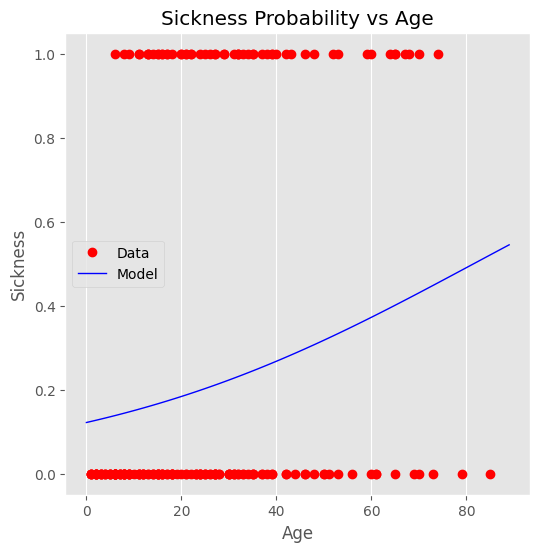

In [148]:
plottitle = 'Sickness Probability vs Age'
make2plot(xobs,Yvec,xaxis_age,fitted,'Age','Sickness',plottitle)

From the plot, it appears that **age** alone is not a strong predictor. The full model is also challenging to interpret directly, which is not unusual in real-world applications.

We now turn to package-based tools for more efficient and interpretable modeling.

We identify:

- The **design matrix** $ X $, which includes all predictors,
- The **target vector** $ y $, which is the binary response.




<!--Age does not appear to be very useful (in fact the entire model is a bit troublesome to interpret)

Now some more formal machine learning using packages; Identify the **design matrix** and the **target** columns.-->

In [149]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['AGE', 'SECTOR']
feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable

We split the dataset into **training** and **testing** subsets to evaluate generalization.

In [150]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

We fit a logistic regression model using the `scikit-learn` package.

This approach provides fitted coefficients, a built-in solver, and standard scoring methods.


In [151]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)

#
y_pred=logreg.predict(X_test)

Model parameters are extracted and compared to the homebrew results. The similarity provides confidence in both implementations.


In [152]:
print(logreg.intercept_[0])
print(logreg.coef_)
#y.head()

-3.8678278714188528
[[ 0.02518861  0.18701833 -0.22604932  1.51451584]]


We evaluate the model’s predictive performance using the `.score()` method.

The resulting accuracy is modest. This prompts us to investigate whether all predictors are needed or if a simpler model might perform just as well.


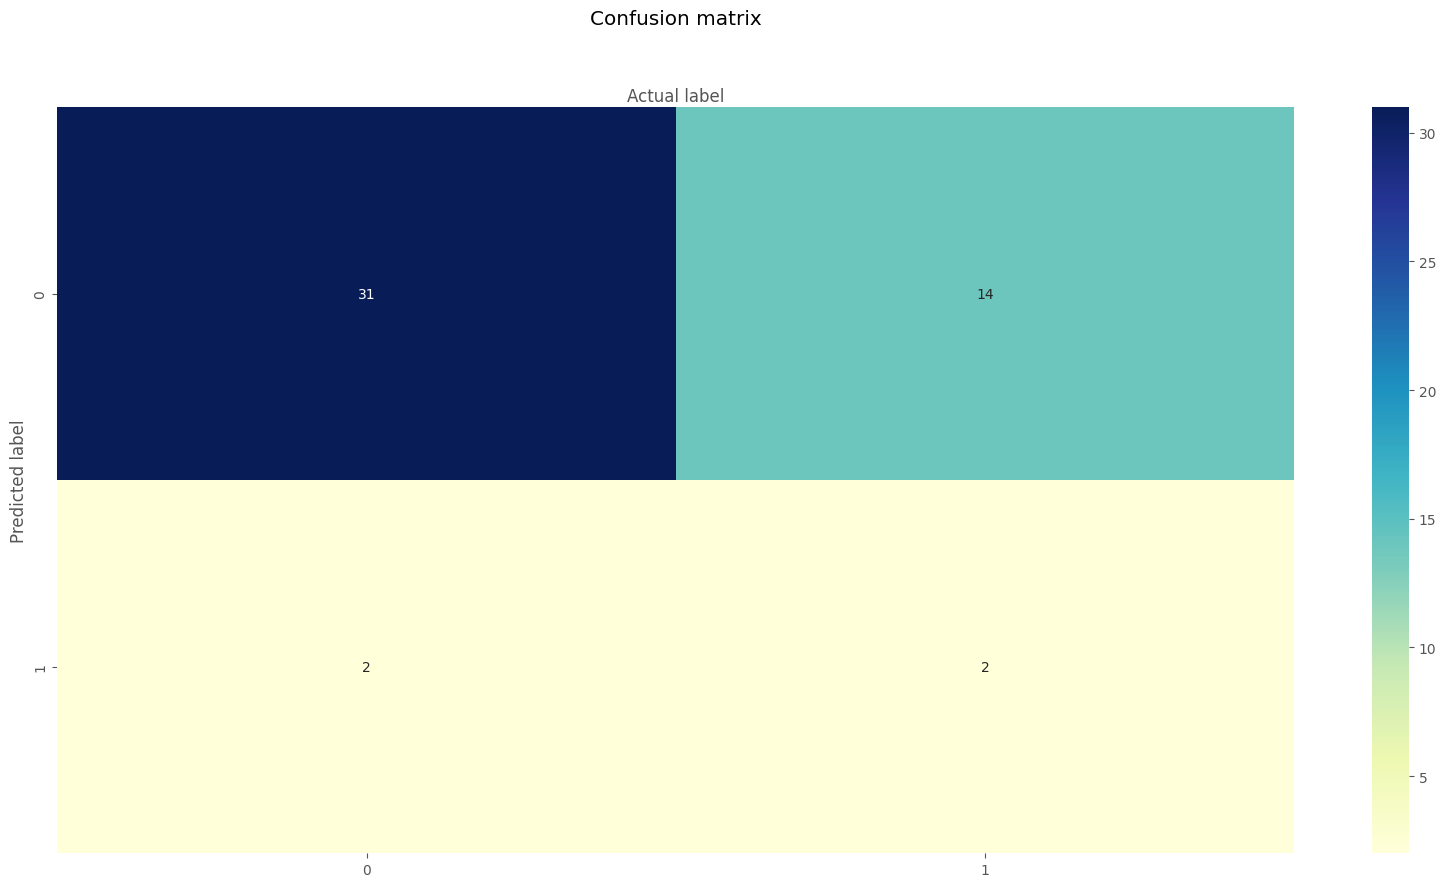

In [153]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

We begin by testing models with fewer predictors to assess their individual contributions.

**First: AGE only**
This isolates the predictive value of age alone.


-1.7238065116617818
[[0.02719036]]


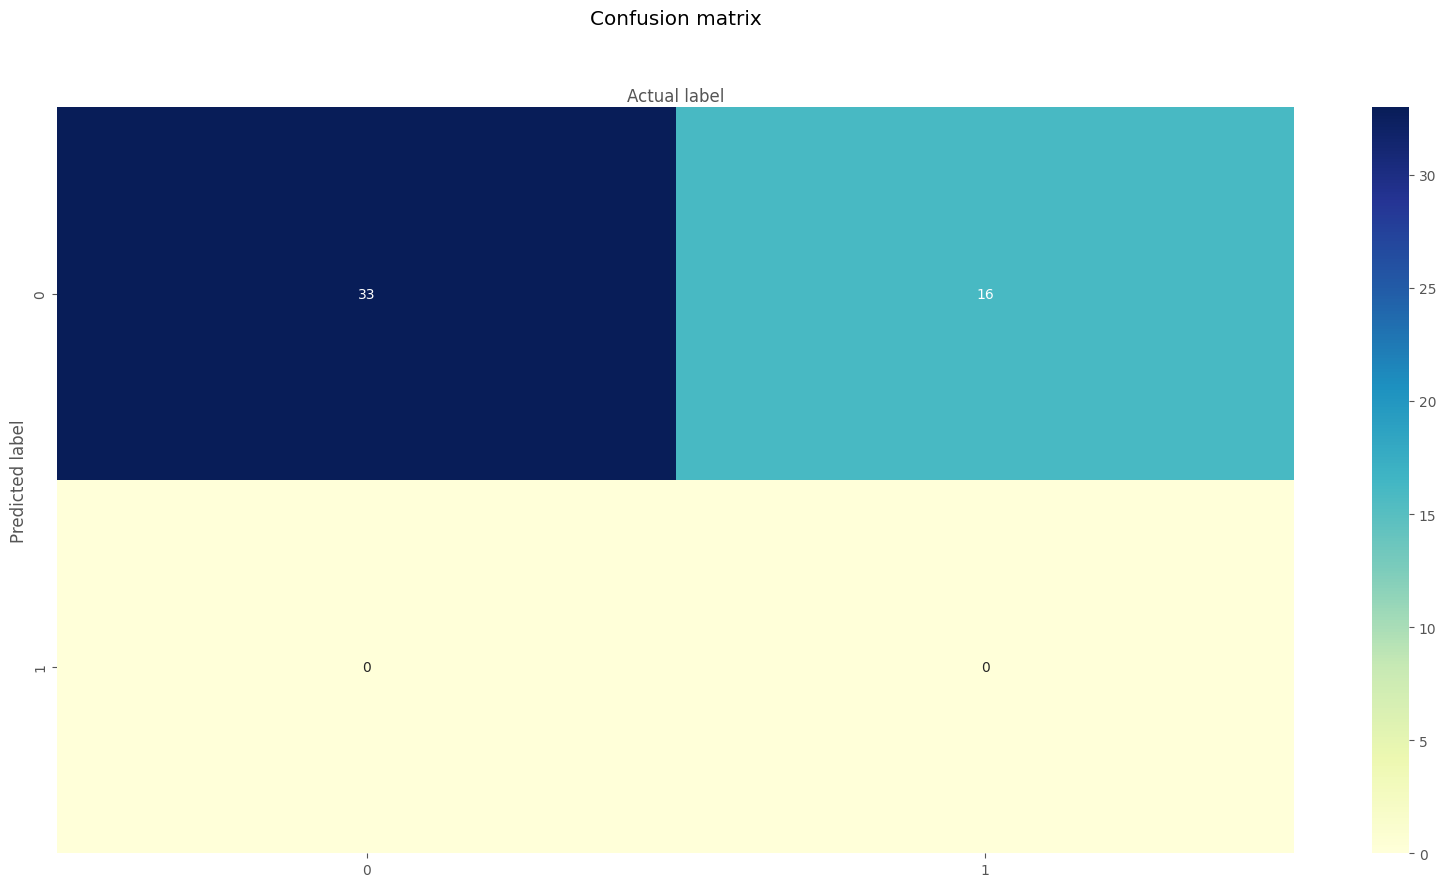

In [154]:
#split dataset in features and target variable
feature_cols = ['AGE']
#feature_cols = ['AGE', 'SECTOR']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)

#
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

**Next: INCOME (X2 and X3) only**
We evaluate the predictive value of socioeconomic status without age or sector.


-1.1389014522629408
[[0.3963004  0.21673499]]


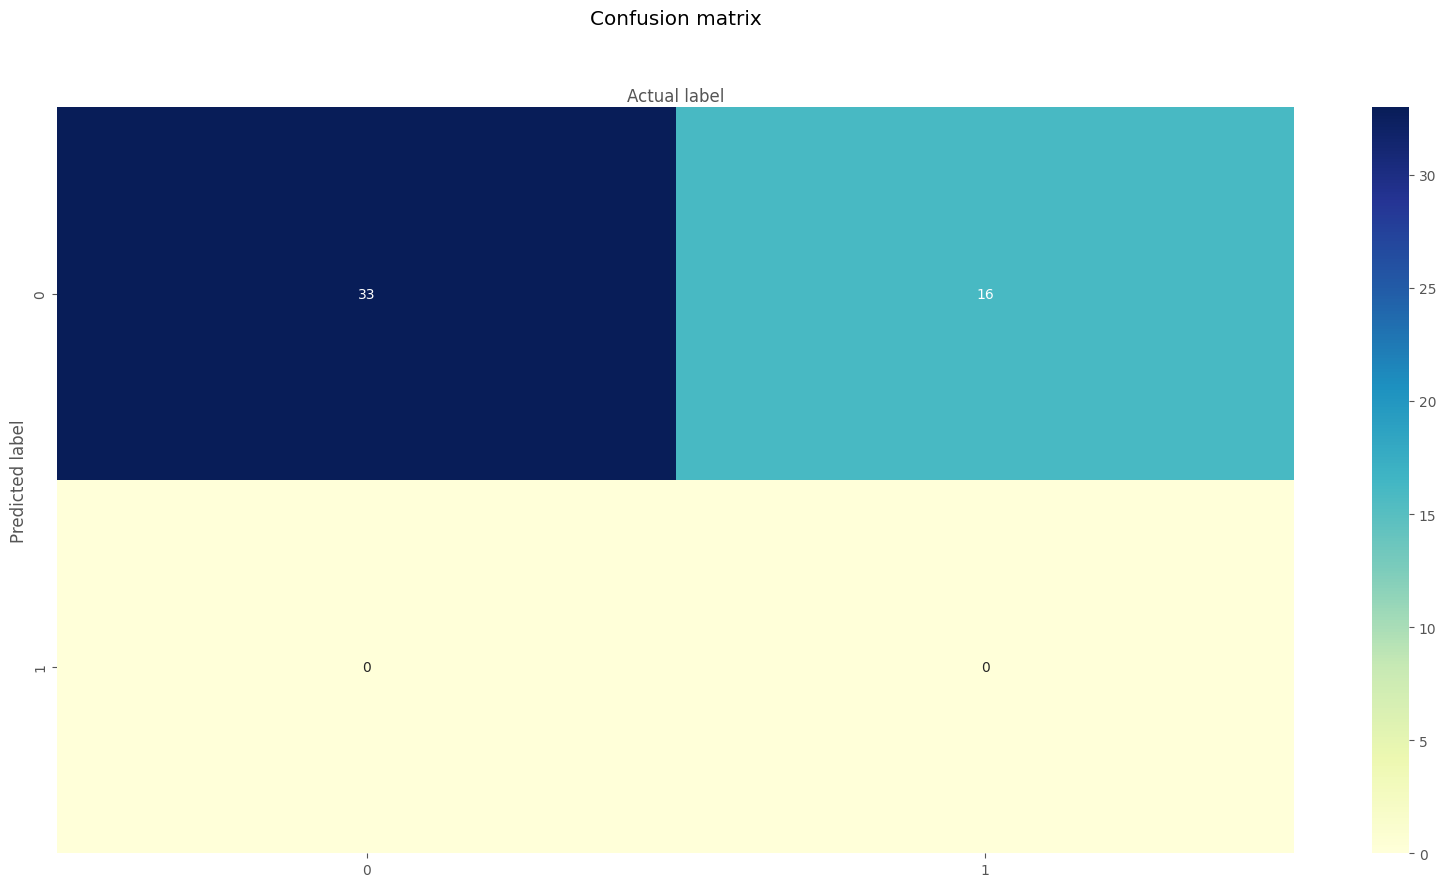

In [155]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['SECTOR']
feature_cols = ['X2','X3']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

**Next: SECTOR only**
We isolate the predictive power of the city sector.


-3.265050761147032
[[1.56248233]]


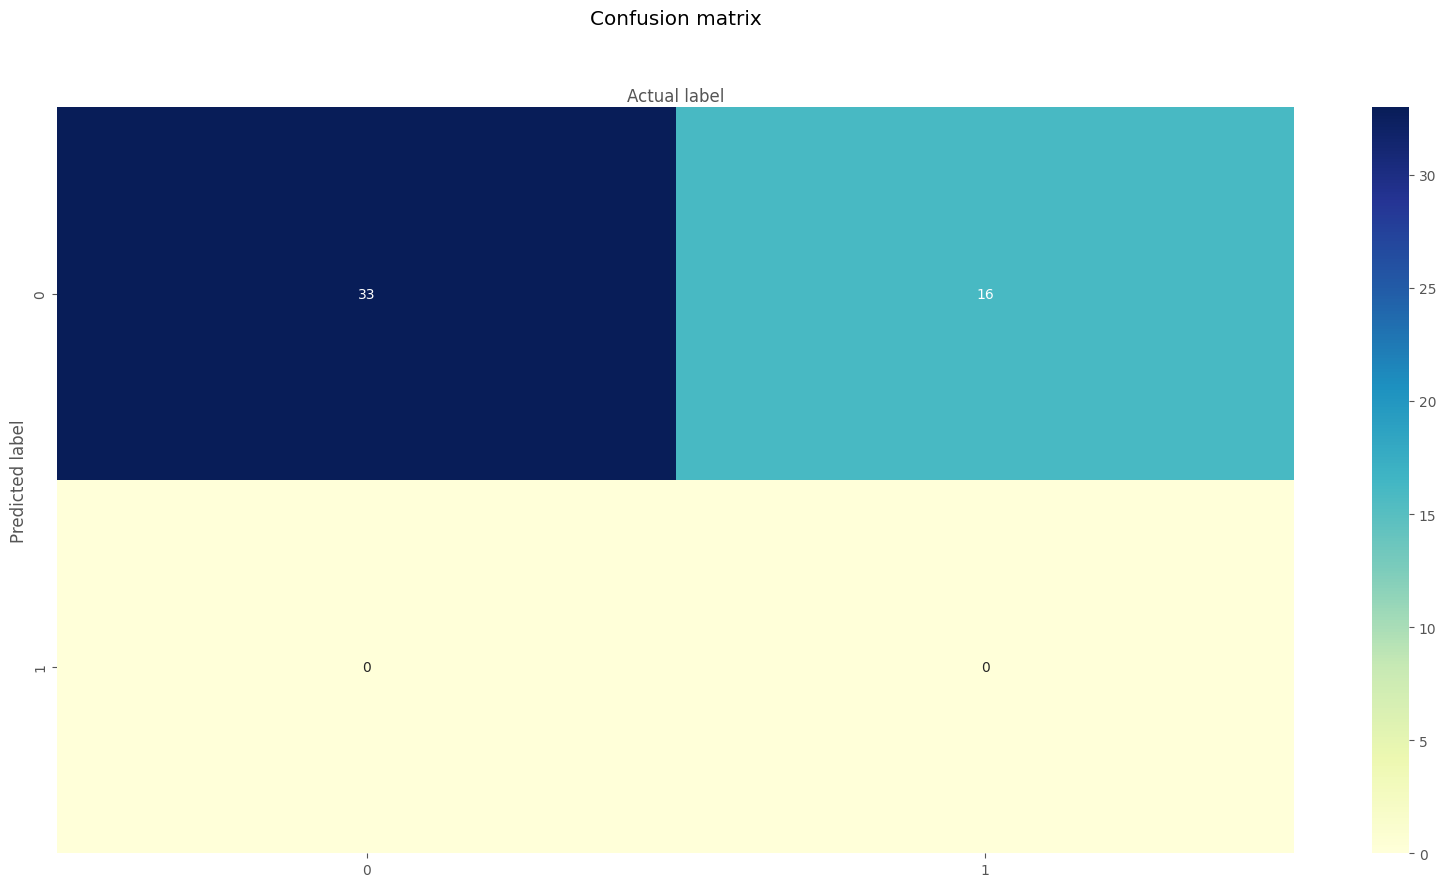

In [156]:
#split dataset in features and target variable
#feature_cols = ['AGE']
feature_cols = ['SECTOR']
#feature_cols = ['X2','X3']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

**Finally: AGE and SECTOR**
We explore whether combining age and sector improves predictive performance.


-3.8498269191334367
[[0.02426237 1.49033741]]


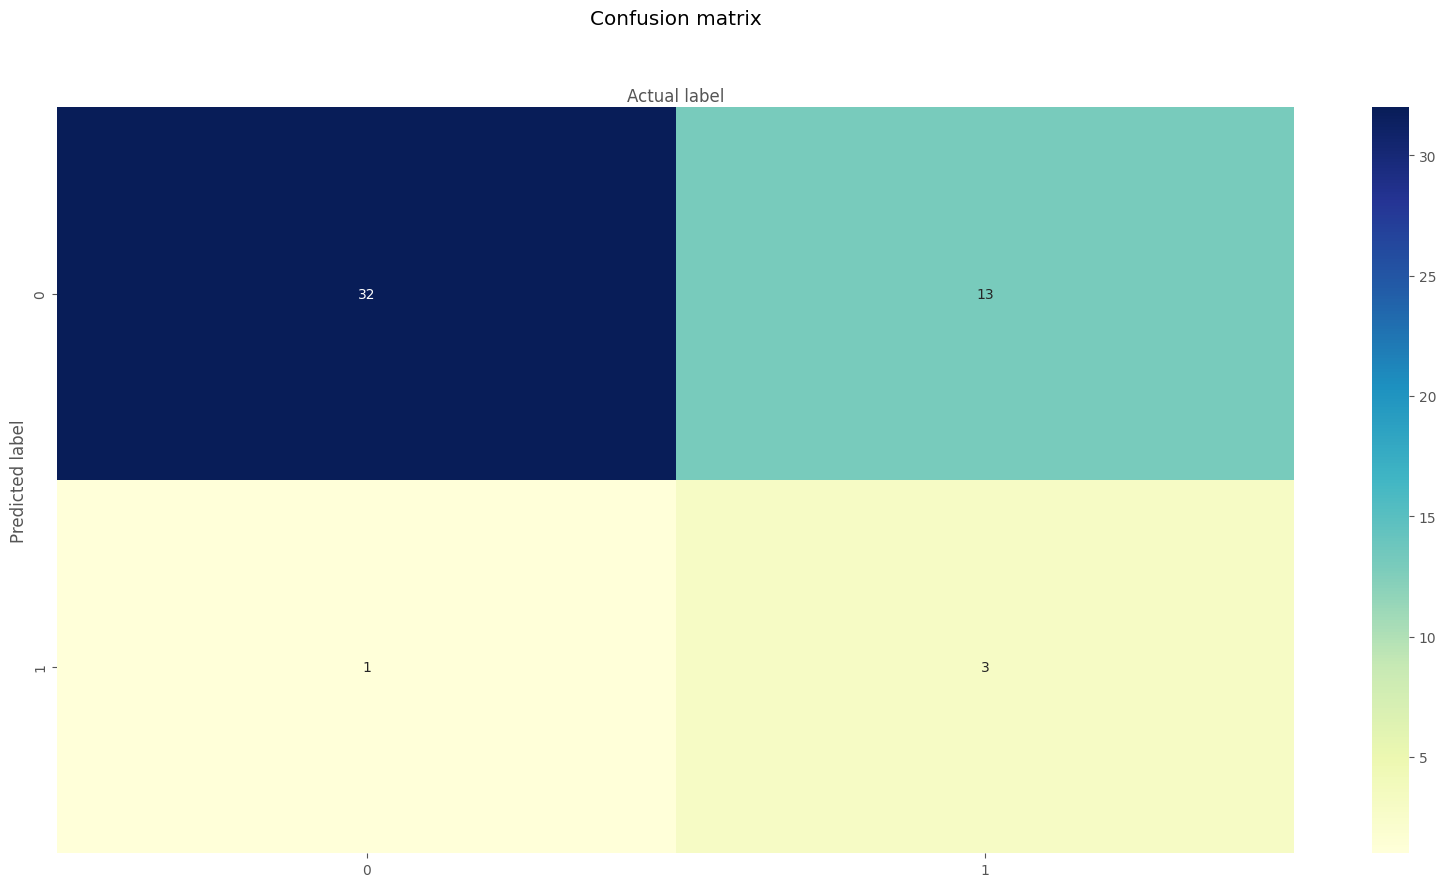

In [157]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['SECTOR']
feature_cols = ['AGE','SECTOR']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

In summary:

- The **full model** did not substantially outperform simpler models.
- **Sector** appears to carry some predictive power, while **age** alone is nearly as informative as the full set.
- **Income** encoding adds some nuance but doesn’t dramatically improve results.

This dataset is known to be somewhat noisy and **underfit**, which makes it a good example of both the strengths and limitations of logistic regression.

The key learning takeaway is that we have decoded and implemented both **manual** and **package-based** multiple logistic regression pipelines—a foundational skill in statistical modeling and machine learning.

# 7.5 Titanic Survival Example (adapted from 2012 Kaggle Competition)

This example uses the dataset for the [2012 Kaggle "Titanic - Machine Learning from Disaster Competition](www.kaggle.com/competitions/titanic/overview/citation).  The dataset is known to be well explained using Multiple Logistic Regression.  

:::{admonition} Verbatin from Kaggle
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).
:::

The variable names in the dataset are:

|variable_name|Alpha Name| Meaning | Notes|
|-------------|---------------|----------------|----------------|
|survival 	|Survival 	|0 = No, 1 = Yes||
|pclass 	|Ticket class 	|1 = 1st, 2 = 2nd, 3 = 3rd||
|sex 	|Sex 	|||
|Age 	|Age in years 	|Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5||
|sibsp 	|# of siblings / spouses aboard the Titanic |Sibling = brother, sister, stepbrother, stepsister<br>Spouse = husband, wife (mistresses and fiancés were ignored)|
|parch 	|# of parents / children aboard the Titanic |Parent = mother, father<br>Child = daughter, son, stepdaughter, stepson<br>Some children travelled only with a nanny, therefore parch=0 for them.||	
|ticket 	|Ticket number 	|||
|fare 	|Passenger fare 	|||
|cabin 	|Cabin number 	|||
|embarked 	|Port of Embarkation 	|C = Cherbourg, Q = Queenstown, S = Southampton| |



In [158]:
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Try to download the dataset from GitHub (fallback to local if needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
filename = "titanic.csv"

if not os.path.exists(filename):
    try:
        response = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Dataset downloaded and saved as '{filename}'")
    except Exception as e:
        print(f"Could not download file. Please ensure '{filename}' is available locally.\n", e)

# Load dataset
df = pd.read_csv(filename)

# Display sample
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [159]:
# Drop columns that are not immediately useful or too messy (Name, Ticket, Cabin)
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

# Handle missing values
df = df.dropna(subset=['Embarked'])              # drop rows with missing Embarked
df['Age'] = df['Age'].fillna(df['Age'].median()) # fill missing Age with median
df['Fare'] = df['Fare'].fillna(df['Fare'].median()) # fill Fare if needed

# Display sample
print(df.head())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    male  22.0      1      0   7.2500        S
1            2         1       1  female  38.0      1      0  71.2833        C
2            3         1       3  female  26.0      0      0   7.9250        S
3            4         1       1  female  35.0      1      0  53.1000        S
4            5         0       3    male  35.0      0      0   8.0500        S


In [160]:
# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = df['Survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)

# Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("\nModel Coefficients and Odds Ratios:")
print(coef_df)


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       111
           1       0.73      0.66      0.69        67

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

Confusion Matrix:
 [[95 16]
 [23 44]]

Model Coefficients and Odds Ratios:
      Feature  Coefficient  Odds Ratio
1         Sex     2.706257   14.973123
5        Fare     0.001798    1.001799
2         Age    -0.037653    0.963047
6  Embarked_Q    -0.066455    0.935705
4       Parch    -0.098388    0.906297
3       SibSp    -0.332609    0.717051
7  Embarked_S    -0.444609    0.641075
0      Pclass    -1.128217    0.323610


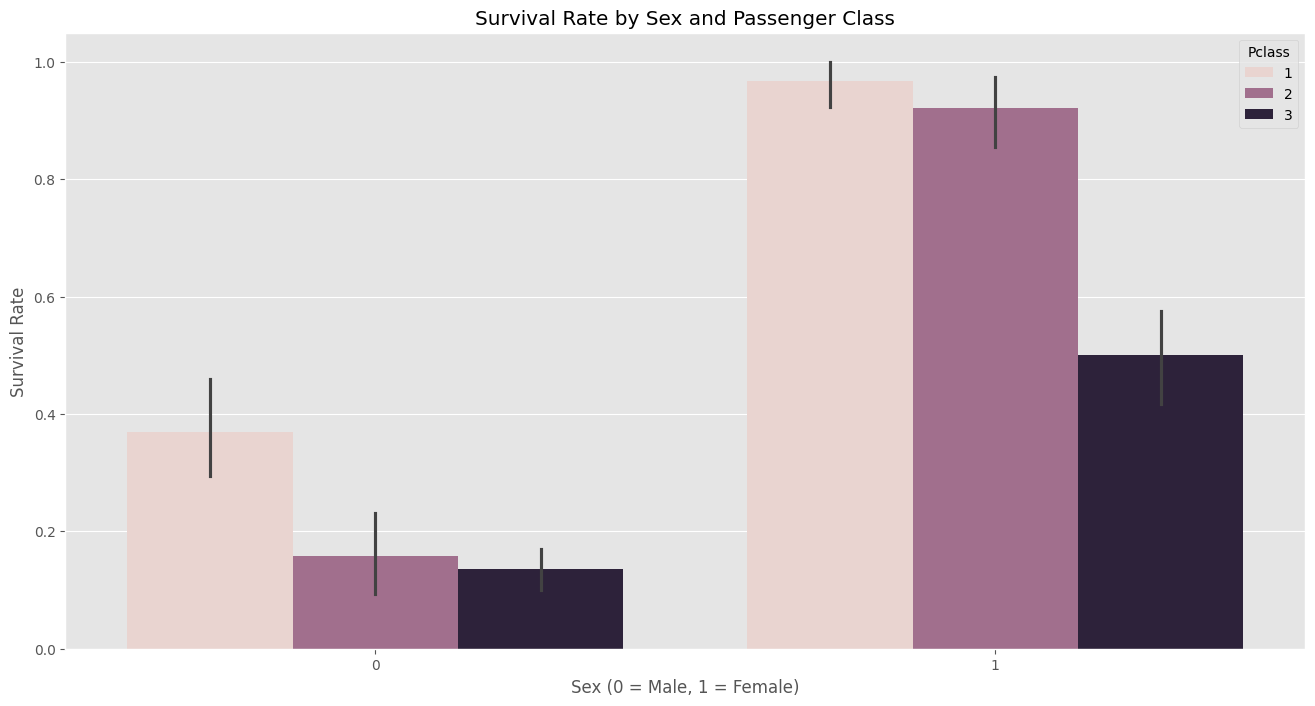

In [161]:
# Plot: Survival rate by Sex and Pclass
sns.barplot(data=df, x='Sex', y='Survived', hue='Pclass')
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Sex (0 = Male, 1 = Female)")
plt.ylabel("Survival Rate")
plt.show()


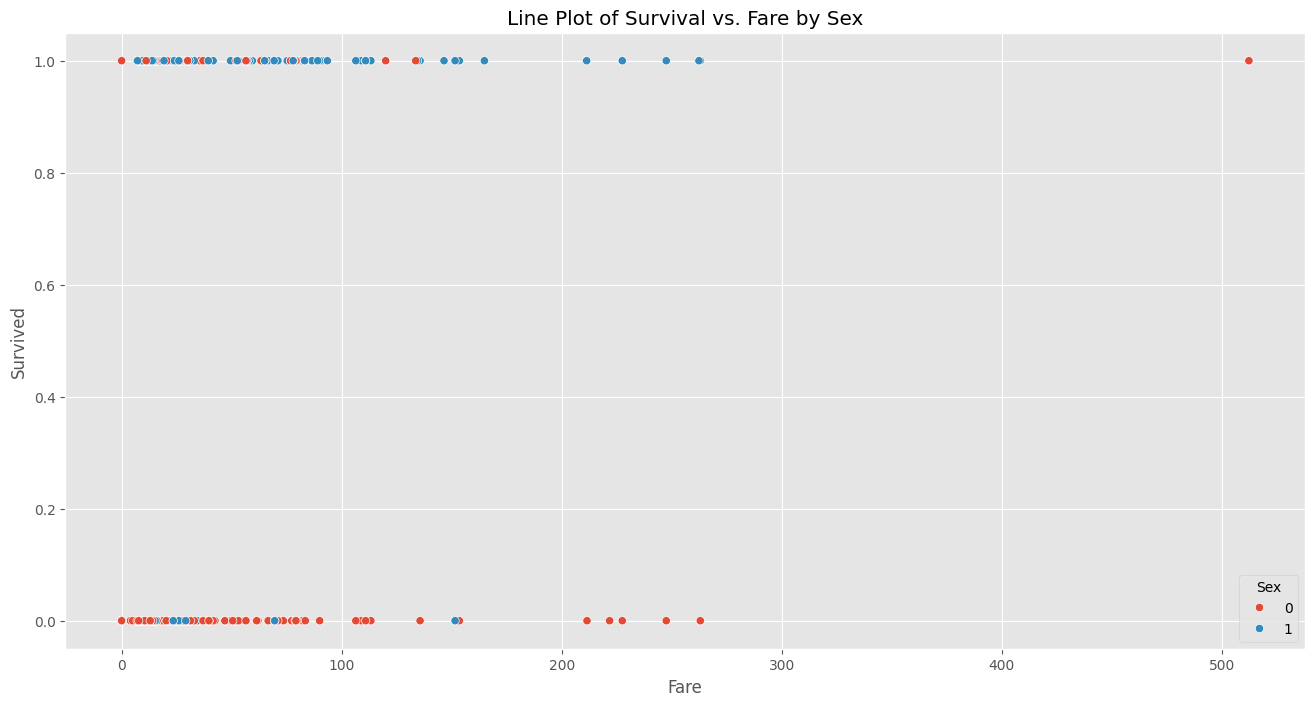

In [162]:

# Plot: Survival rate by Sex and Pclass
sns.scatterplot(x="Fare", y="Survived", hue="Sex", data=df)
plt.title("Line Plot of Survival vs. Fare by Sex")
plt.show()


The sex-classified plot is interesting in that fare (wealth) is less of an indicator of survival than one might expect (its kind of same for recent plane wrecks); but lets explore anyway - is the median fare for surviving females different from that of males.  Just by visual inspection, yes - but how much?

So one way to handle is to modify our script to do two logistic models; survival vs fare for males, and again for females.

In [163]:
filtered_male_df = df.loc[df['Sex'] == 0]
# Features and target
X = filtered_male_df[['Fare']]
y = filtered_male_df['Survived']
#print(len(X))

In [164]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)

In [165]:
# Fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train);

In [166]:
# Evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91        99
           1       0.00      0.00      0.00        17

    accuracy                           0.84       116
   macro avg       0.43      0.49      0.46       116
weighted avg       0.73      0.84      0.78       116

Confusion Matrix:
 [[97  2]
 [17  0]]


In [167]:
X_train.describe()

,Fare
count,461.000000
mean,25.326824
std,44.374488
min,0.000000
25%,7.854200
50%,11.500000
75%,26.550000
max,512.329200


In [168]:
import warnings
warnings.filterwarnings('ignore')
# Predict probability over grid
x_pred = np.linspace(0, 500, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]

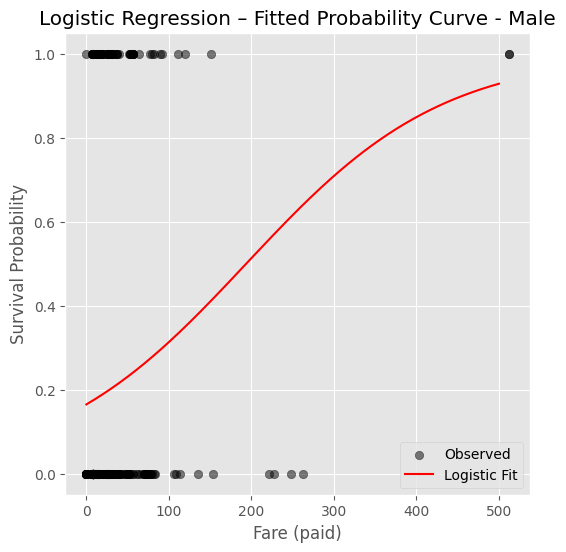

In [169]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Fare (paid)")
plt.ylabel("Survival Probability")
plt.title("Logistic Regression – Fitted Probability Curve - Male")
plt.legend()
plt.grid(True)
plt.show()

So a logistic model fit suggests that a male who paid a fare over 200 pounds, has a probability of survival in excess of 50\%, if paid less then likely not to survive (notice from the plotted observations your chances are kind of crummy anyway).  Now repeating the analysis for females:

In [170]:
import warnings
warnings.filterwarnings('ignore')
filtered_female_df = df.loc[df['Sex'] == 1]
# Features and target
X = filtered_female_df[['Fare']]
y = filtered_female_df['Survived']
print(len(X))
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)
# Fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict probability over grid
x_pred = np.linspace(0, 500, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]

312


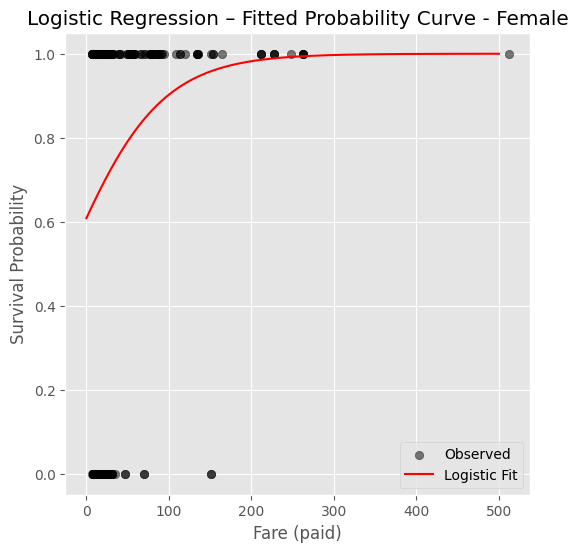

In [171]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Fare (paid)")
plt.ylabel("Survival Probability")
plt.title("Logistic Regression – Fitted Probability Curve - Female")
plt.legend()
plt.grid(True)
plt.show()

So from this plot the logistic model suggests just being female confers a huge survival advantage regardless of wealth.  

# 7.6 Poison Mushrooms

Mushroom foraging is a practice with both cultural significance and serious risks. Many
wild mushrooms are edible and nutritious, but others contain potent toxins that can
cause severe illness or death, even in small quantities. While advanced techniques
like High-Performance Liquid Chromatography (HPLC) and mass spectrometry can
accurately identify toxic compounds, these methods are laboratory-based, expensive,
and time-consuming—making them impractical for real-time decision-making in the
field. For amateur foragers, park rangers, and even emergency responders, the ability
to assess toxicity risk based on visible features—such as cap color, gill shape, bruising
reactions, and habitat—is far more practical, if not lifesaving.

This example seeks a machine learning classification algorithm to predict whether a
mushroom is edible or poisonous based on easily observable characteristics. 
The training dataset is drawn from field guide-style descriptions, not lab tests, mimicking how
a forager might gather information in the wild.

## Problem Statement
Using the database description at:

[http://54.243.252.9/ce-5319-webroot/2-Exercises/ES-2/agaricus-lepiota.names](http://54.243.252.9/ce-5319-webroot/2-Exercises/ES-2/agaricus-lepiota.names) 

and the encoded database at:

[http://54.243.252.9/ce-5319-webroot/2-Exercises/ES-2/agaricus-lepiota.data](http://54.243.252.9/ce-5319-webroot/2-Exercises/ES-2/agaricus-lepiota.data)

build a suitable prediction engine to classify a mushroom as poison or non-poison.
Apply your model on the mushroom *Coprinopsis atramentaria* which has the characteristics below:

Coprinopsis atramentaria (Black Ink Cap) Feature Encoding

|Feature #	|Feature Name	|Likely Value|	Code	|Justification|
|-----------|---------------|------------|----------|-------------|
|1|Cap shape|conical|c|Young cap is conical or bell-shaped, becoming more flattened later|
|2|Cap surface|smooth|s|Smooth surface|
|3|Cap color|gray|g|Gray to brownish gray|
|4|Bruises?|no|f|Does not bruise distinctively|
|5|Odor|none|n|Mild or no odor|
|6|Gill attachment|free|f|Gills free from the stalk|
|7|Gill spacing|crowded|w|Gills are crowded|
|8|Gill size|broad|b|Broad gills, typical of inky caps|
|9|Gill color|black|k|Turns black and dissolves into ink|
|10|Stalk shape|tapering|t|Often narrows at base|
|11|Stalk root|rooted|r|Rooted in soil (some sources say “equal”)|
|12|Stalk surface above ring|smooth|s|Smooth texture|
|13|Stalk surface below ring|smooth|s|Smooth texture|
|14|Stalk color above ring|gray|g|Gray to whitish|
|15|Stalk color below ring|gray|g|Same as above|
|16|Veil type|partial|p|Has a fleeting partial veil|
|17|Veil color|white|w|Veil is whitish when present|
|18|Ring number|one|o|One ring from partial veil|
|19|Ring type|evanescent|e|Ring disappears quickly|
|20|Spore print color|black|k|Produces a black spore print|
|21|Population|scattered|s|Grows in scattered groups|
|22|Habitat|urban|u|Often found in grassy areas, roadsides, lawns (urban-ish)|

The feature vector in the format of the database is : `csgfnfwbktrssggpwoeksu`

Sources for the table above include Wikipedia

>...Measuring 3–10 centimetres in diameter, the greyish or brownish-grey cap is furrowed,
initially bell-shaped, and later more convex, splitting at the margin. It melts from the
outside in. The very crowded gills are free; they are white at first, then grey or pinkish
and turn black and deliquesce.
The stipe measures 5–17 cm high by 1–2 cm thick, is grey in colour, and lacks a ring.
In young groups, the stems may be obscured by the caps. The spore print is black and
the almond-shaped spores measure 8–11 by 5–6 μm. The flesh is thin and pale grey in
colour.
It is commonly associated with buried wood and is found in grassland, meadows,
disturbed ground, and open terrain from late spring to autumn. Like many ink caps,
it grows in tufts.

:::{warning}
This example is to illustrate ML tools, <span style="color:red; font-weight:bold;">DO NOT USE THIS EXAMPLE FOR REAL MUSHROOM SAFETY DETERMINATION</span>
:::

### ML Workflow

**Download the database from remote server**  

:::{note}
While the dataset is already available locally on the server, this step intentionally simulates retrieving data from a persistent, remote source. This reflects a common pattern in real-world workflows, where data is often accessed from version-controlled or centralized storage systems rather than hardcoded locations.
:::

In [46]:
import sys # Module to process commands to/from the OS using a shell-type syntax
import requests
remote_url="http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/logisticregression/agaricus-lepiota.data"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
localfile = open('poisonmushroom.csv','wb') # open connection to a local file same name as remote
localfile.write(rget.content) # extract from the remote the contents,insert into the local file same name
localfile.close() # close connection to the local file
# delete file if it exists

**Load the database into a dataframe** 
1. Load the file downloaded suitable pandas tools.
2. Create an attribute list with meaningful (to us humans) names for the database columns.
3. Update the column names using a mapping method. In this example, a `for` loop creates a dictionary that maps default column indices to meaningful attribute names. Bear in mind later on this setp will create a warning, but it is suppressed intentionally. Alternatively, we could have directly assigned the list to df.columns, used a zipped dictionary, or applied set_axis()—each option has different strengths in terms of clarity, safety, and style.
4. List the revised database (here I choose the first 20 rows, recall the default is 5)

:::{note}
Some other ways to handle the column naming are:

1. ```python
   mymushroom.columns = attributes
   ```
A concise approach that assumes the number of columns exactly matches the number of attributes (len(attributes) == mymushroom.shape[1]).  This approach may raise `ValueError` if mismatched

2. ```python
   mymushroom = mymushroom.rename(columns=dict(zip(mymushroom.columns, attributes)))
   ```
A succinct and expressive mapping concept but all in a single line. Easily extended if only renaming a subset. Still assumes 1-to-1 mapping (i.e., same lengths)

3. ```python
   mymushroom = mymushroom.set_axis(attributes, axis=1, inplace=False)
   ```
Functionally equivalent to .columns = ... Can be method chained: df.set_axis(...).dropna() etc.

:::

In [47]:
import pandas as pd
mymushroom = pd.read_csv('poisonmushroom.csv',header=None)

attributes=['poison-class','cap-shape','cap-surface','cap-color','bruises','odor','gill-attachment','gill-spacing','gill-size','gill-color','stalk-shape','stalk-root','stalk-surface-above-ring','stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring','veil-type','veil-color','ring-number','ring-type','spore-print-color','population','habitat']
len(attributes)

req_col_names = attributes
curr_col_names = list(mymushroom.columns)

mapper = {}
for i, name in enumerate(curr_col_names):
    mapper[name] = req_col_names[i]

mymushroom = mymushroom.rename(columns=mapper)
interim = pd.DataFrame(mymushroom)
mymushroom.head(20)

,poison-class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


**Encode the feature list** into numeric values.

The steps below handle the encoding using a cipher substution approach, there are undoubtably better ways to handle the encoding.  
The functions below are NOT one-hot encoding.  

Each function interprets the feature value based on position in the vector, and uses the alphabet for that feature to assign a numeric value for the feature.

:::{note}
This is a good example of when to use a LLM to help improve our code.
:::

In [48]:
def p0(stringvalue):
    if stringvalue == 'e':
        p0 = 0
    elif stringvalue == 'p':
        p0 = 1
    else: 
        raise Exception("Encoding failed in p0 missing data maybe?")
    return(p0)
######################################################################
# Feature Encoding Functions using a Simple Substitution Cipher     ##
######################################################################
def c1(stringvalue):
#cap-shape:  bell=b,conical=c,convex=x,flat=f,knobbed=k,sunken=s
    ncode=True # set exception flag
    alphabet=['b','c','x','f','k','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c1=i+1
            ncode=False #  if encoding swithc flag value
    if ncode:
        raise Exception("Encoding failed in c1 missing data maybe?")
    return(c1)
######################################################################
def c2(stringvalue):
#cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
    ncode=True
    alphabet=['f','g','y','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c2=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c2 missing data maybe?")
    return(c2)
######################################################################
def c3(stringvalue):
#cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','r','p','u','e','w','y']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c3=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c3 missing data maybe?")
    return(c3)
######################################################################
def c4(stringvalue): #this is a simple binary encoding column
#bruises?:bruises=t,no=f
    ncode=True
    alphabet=['f','t']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c4=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c4 missing data maybe?")
    return(c4)
######################################################################
def c5(stringvalue):
#odor:  almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
    ncode=True
    alphabet=['a','l','c','y','f','m','n','p','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c5=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c5 missing data maybe?")
    return(c5)
######################################################################
def c6(stringvalue):
#gill-attachment: attached=a,descending=d,free=f,notched=n
    ncode=True
    alphabet=['a','d','f','n']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c6=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c6 missing data maybe?")
    return(c6)
######################################################################
def c7(stringvalue):
#gill-spacing: close=c,crowded=w,distant=d
    ncode=True
    alphabet=['c','w','d']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c7=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c7 missing data maybe?")
    return(c7)
######################################################################
def c8(stringvalue):
#gill-size:  broad=b,narrow=n
    ncode=True
    alphabet=['b','n']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c8=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c8 missing data maybe?")
    return(c8)
######################################################################
def c9(stringvalue):
#gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g,green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y
    ncode=True
    alphabet=['k','n','b','h','g','r','o','p','u','e','w','y']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c9=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c9 missing data maybe?")
    return(c9)
######################################################################
def c10(stringvalue):
#stalk-shape:enlarging=e,tapering=t
    ncode=True
    alphabet=['e','t']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c10=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c10 missing data maybe?")
    return(c10)
######################################################################
def c11(stringvalue):
#stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
    ncode=True
    alphabet=['b','c','u','e','z','r','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c11=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c11 missing data maybe?")
    return(c11)
######################################################################
def c12(stringvalue):
#stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
    ncode=True
    alphabet=['f','y','k','s','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c12=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c12 missing data maybe?")
    return(c12)
######################################################################
def c13(stringvalue):
#stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
    ncode=True
    alphabet=['f','y','k','s','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c13=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c13 missing data maybe?")
    return(c13)
######################################################################
def c14(stringvalue):
#stalk-color-above-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','o','p','e','w','y'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c14=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c14 missing data maybe?")
    return(c14)
######################################################################
def c15(stringvalue):
#stalk-color-below-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','o','p','e','w','y'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c15=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c15 missing data maybe?")
    return(c15)
######################################################################
def c16(stringvalue):
#veil-type:                partial=p,universal=u
    ncode=True
    alphabet=['p','u'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c16=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c16 missing data maybe?")
    return(c16)
######################################################################
def c17(stringvalue):
#veil-color:               brown=n,orange=o,white=w,yellow=y
    ncode=True
    alphabet=['n','o','w','y'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c17=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c17 missing data maybe?")
    return(c17)
######################################################################
def c18(stringvalue):
#ring-number:              none=n,one=o,two=t
    ncode=True
    alphabet=['n','o','t'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c18=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c18 missing data maybe?")
    return(c18)
######################################################################
def c19(stringvalue):
#ring-type:  cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
    ncode=True
    alphabet=['c','e','f','l','n','p','s','z'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c19=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c19 missing data maybe?")
    return(c19)
######################################################################
def c20(stringvalue):
#spore-print-color:        black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
    ncode=True
    alphabet=['k','n','b','h','r','o','u','w','y','?'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c20=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c20 missing data maybe?")
    return(c20)
######################################################################
def c21(stringvalue):
#population:abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
    ncode=True
    alphabet=['a','c','n','s','v','y','?'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c21=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c21 missing data maybe?")
    return(c21)
######################################################################
def c22(stringvalue):
# habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d   
    ncode=True
    alphabet=['g','l','m','p','u','w','d']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c22=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c22 missing data maybe?")
    return(c22)

interim['poison-class']            = mymushroom['poison-class'].apply(p0)
interim['cap-shape']               = mymushroom['cap-shape'].apply(c1)
interim['cap-surface']             = mymushroom['cap-surface'].apply(c2)
interim['cap-color']               = mymushroom['cap-color'].apply(c3)
interim['bruises']                 = mymushroom['bruises'].apply(c4)
interim['odor']                    = mymushroom['odor'].apply(c5)
interim['gill-attachment']         = mymushroom['gill-attachment'].apply(c6)
interim['gill-spacing']            = mymushroom['gill-spacing'].apply(c7)
interim['gill-size']               = mymushroom['gill-size'].apply(c8)
interim['gill-color']              = mymushroom['gill-color'].apply(c9)
interim['stalk-shape']             = mymushroom['stalk-shape'].apply(c10)
interim['stalk-root']              = mymushroom['stalk-root'].apply(c11)
interim['stalk-surface-above-ring']= mymushroom['stalk-surface-above-ring'].apply(c12)
interim['stalk-surface-below-ring']= mymushroom['stalk-surface-below-ring'].apply(c13)
interim['stalk-color-above-ring']  = mymushroom['stalk-color-above-ring'].apply(c14)
interim['stalk-color-below-ring']  = mymushroom['stalk-color-below-ring'].apply(c15)
interim['veil-type']               = mymushroom['veil-type'].apply(c16)
interim['veil-color']              = mymushroom['veil-color'].apply(c17)
interim['ring-number']             = mymushroom['ring-number'].apply(c18)
interim['ring-type']               = mymushroom['ring-type'].apply(c19)
interim['spore-print-color']       = mymushroom['spore-print-color'].apply(c20)
interim['population']              = mymushroom['population'].apply(c21)
interim['habitat']                 = mymushroom['habitat'].apply(c22)

interim.head(10)

,poison-class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,3,4,1,2,8,3,1,2,1,...,4,8,8,1,3,2,6,1,4,5
1,0,3,4,10,2,1,3,1,1,1,...,4,8,8,1,3,2,6,2,3,1
2,0,1,4,9,2,2,3,1,1,2,...,4,8,8,1,3,2,6,2,3,3
3,1,3,3,9,2,8,3,1,2,2,...,4,8,8,1,3,2,6,1,4,5
4,0,3,4,4,1,7,3,2,1,1,...,4,8,8,1,3,2,2,2,1,1
5,0,3,3,10,2,1,3,1,1,2,...,4,8,8,1,3,2,6,1,3,1
6,0,1,4,9,2,1,3,1,1,5,...,4,8,8,1,3,2,6,1,3,3
7,0,1,3,9,2,2,3,1,1,2,...,4,8,8,1,3,2,6,2,4,3
8,1,3,3,9,2,8,3,1,2,8,...,4,8,8,1,3,2,6,1,5,1
9,0,1,4,10,2,1,3,1,1,5,...,4,8,8,1,3,2,6,1,4,3


**Use `sklearn` to built training and testing data sets**
1. Split the database
2. Examine outputs to verify maintain structure.

In [49]:
#split dataset in features and target variable
feature_cols = attributes[1:]
X = interim[feature_cols] # Features
y = interim['poison-class'] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [50]:
X_train.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5832,4,3,10,1,5,3,1,1,8,1,...,3,2,1,1,3,2,4,4,6,1
601,3,3,1,2,2,3,1,1,11,1,...,2,8,8,1,3,2,6,2,6,1
1601,4,4,4,1,7,3,2,1,1,2,...,1,8,8,1,3,2,2,1,1,1
4941,3,1,4,1,5,3,1,1,5,1,...,3,2,6,1,3,2,4,4,5,4
7492,4,3,1,1,5,3,1,2,3,2,...,3,6,8,1,3,2,2,8,5,7


In [51]:
y_train.head()

5832    1
601     0
1601    0
4941    1
7492    1
Name: poison-class, dtype: int64

In [52]:
X_test.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
380,3,3,1,2,8,3,1,2,8,1,...,4,8,8,1,3,2,6,1,4,5
3641,4,3,4,2,7,3,1,1,8,2,...,4,4,4,1,3,2,6,1,6,7
273,3,3,10,2,1,3,1,1,1,1,...,4,8,8,1,3,2,6,2,3,3
1029,3,4,9,1,7,3,2,1,1,2,...,4,8,8,1,3,2,2,1,1,1
684,3,1,1,2,7,3,1,1,8,2,...,4,6,8,1,3,2,6,2,5,7


In [53]:
y_test.head()

380     1
3641    0
273     0
1029    0
684     0
Name: poison-class, dtype: int64

**Load the `sklearn` Logistic Regression package**
1. Load the package into notebook
2. Create an instance of the model.
3. Fit on traning set
4. Predict on test set

In [54]:
# import the method
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(max_iter=1000)
# fit the model with data
logreg.fit(X_train,y_train)
# predict the test set
y_pred=logreg.predict(X_test)
# 

**Report Results**
1. Examine logistic constants (gives idea of importantce of specific features)
2. Confusion matrix as heatmap

In [55]:
print("Logistic Regression Values")
print("Intercept:", logreg.intercept_[0])
print("Feature Coefficients: \n",logreg.coef_)

Logistic Regression Values
Intercept: 16.542399116671376
Feature Coefficients: 
 [[-0.11042847  1.09064506  0.08741523 -3.45823817  0.14263106  0.24391943
  -9.04357091  7.79074285 -0.11221928 -0.07236673 -2.05036577 -0.70728185
  -0.04710663 -0.30924264  0.34523294  0.24430201  0.02944439 -0.82700158
  -0.86654293  0.46866517 -0.59647226 -0.19592944]]


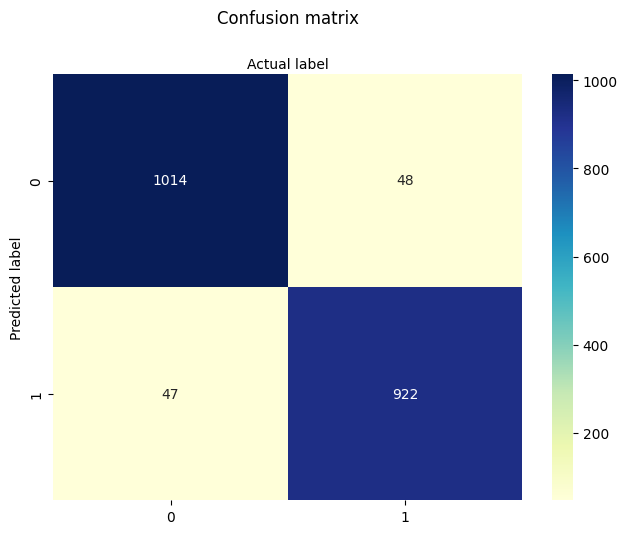

In [56]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

**Classify the new mushroom**  
This is the deployment step — the whole point is to build a prediction engine!

1. Here we simply provide the feature vector values.  
2. A practical improvement would be to create a user interface that prompts for inputs.

:::{note}
Although the classifier correctly predicts this mushroom as edible, there's an important caveat: it is only safe to consume if the person has no alcohol in their system. A compound in the mushroom reacts with alcohol to form a liver toxin — a detail the model cannot detect because this biologically relevant interaction was not part of the training data.

This highlights a key limitation of data-driven models: accurate prediction depends on having **all relevant features** represented. In this case, domain knowledge reveals a missing causal factor, reminding us that models should be used as **tools**—not oracles.
:::

In [57]:
import warnings
warnings.filterwarnings("ignore")
s_new = "csgfnfwbktrssggpwoeksu"
x_new =[c1(s_new[0]),c2(s_new[1]),c3(s_new[2]),c4(s_new[3]),c5(s_new[4]),c6(s_new[5]),c7(s_new[6]),c8(s_new[7]),c9(s_new[8]),c10(s_new[9]),c11(s_new[10]),
           c12(s_new[11]),c13(s_new[12]),c14(s_new[13]),c15(s_new[14]),c16(s_new[15]),c17(s_new[16]),c18(s_new[17]),c19(s_new[18]),c20(s_new[19]),c21(s_new[20]),c22(s_new[21]) ]
#print(x_new)
y_new = logreg.predict(np.array(x_new).reshape(1, -1))  # 1 sample, all features
if y_new < 1 :
    print("New mushroom classified as EDIBLE")
else:
    print("New mushroom classified as POISONIOUS")
    

New mushroom classified as EDIBLE


# 7.6.1 OpenAI Assisted Refactoring
The code below is a result of supplying the code above, and supplying the prompt:

> Can you examine the code and suggest alternate ways to generate the column names? (ie what i called the mapper method) I am using a mapping method in a `for` loop to change existing names (if any) to these listed names.  Bear in mind later on this will create a warning, but it is suppressed intentionally.

Later on when we get to the encoding step the OpenAI prompt was:

> The encoding steps are using a simple-cipher substution approach. The functions below are NOT intended for one-hot encoding.  Each function interprets the feature value based on position in the vector, and uses the reduced alphabet for that feature to assign a numeric value for the feature.  Can you refactor to generalize the encoding - namely to avoid having multiple functions, so I can process any string of correct length and alphabet?

These two prompts provided enough refactored code for the program below, which is more generic and modular - hence should be easier to maintain and apply for other situations.


Logistic Regression Values
Intercept: 16.542399116671376
Feature Coefficients: 
 [[-0.11042847  1.09064506  0.08741523 -3.45823817  0.14263106  0.24391943
  -9.04357091  7.79074285 -0.11221928 -0.07236673 -2.05036577 -0.70728185
  -0.04710663 -0.30924264  0.34523294  0.24430201  0.02944439 -0.82700158
  -0.86654293  0.46866517 -0.59647226 -0.19592944]]
New mushroom classified as EDIBLE


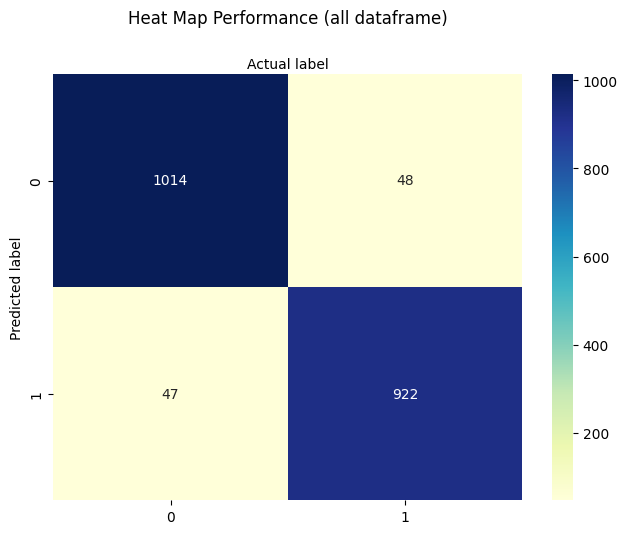

In [59]:
# 7.6.1 Improved code (using OpenAI assisted refactoring)
##########################################################################################################################
##### Encoding definitions: (ordered list of categories, starting index for ordinal encoding)#############################
##########################################################################################################################
encodings = {
    'poison-class':               (['e', 'p'], 0),
    'cap-shape':                  (['b','c','x','f','k','s'], 1),
    'cap-surface':                (['f','g','y','s'], 1),
    'cap-color':                  (['n','b','c','g','r','p','u','e','w','y'], 1),
    'bruises':                    (['f','t'], 1),
    'odor':                       (['a','l','c','y','f','m','n','p','s'], 1),
    'gill-attachment':            (['a','d','f','n'], 1),
    'gill-spacing':              (['c','w','d'], 1),
    'gill-size':                 (['b','n'], 1),
    'gill-color':                (['k','n','b','h','g','r','o','p','u','e','w','y'], 1),
    'stalk-shape':              (['e','t'], 1),
    'stalk-root':               (['b','c','u','e','z','r','?'], 1),
    'stalk-surface-above-ring':(['f','y','k','s','?'], 1),
    'stalk-surface-below-ring':(['f','y','k','s','?'], 1),
    'stalk-color-above-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'stalk-color-below-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'veil-type':               (['p','u'], 1),
    'veil-color':              (['n','o','w','y'], 1),
    'ring-number':             (['n','o','t'], 1),
    'ring-type':               (['c','e','f','l','n','p','s','z'], 1),
    'spore-print-color':       (['k','n','b','h','r','o','u','w','y','?'], 1),
    'population':              (['a','c','n','s','v','y','?'], 1),
    'habitat':                 (['g','l','m','p','u','w','d'], 1)
}
##########################################################################################################################
###### Define Encoder Generator ##########################################################################################
##########################################################################################################################
def make_encoder(alphabet, offset=1, name='feature'):
    def encoder(val):
        if val in alphabet:
            return alphabet.index(val) + offset
        raise Exception(f"Encoding failed in '{name}': unknown value '{val}'")
    return encoder
##########################################################################################################################
##### Apply Encodings ####################################################################################################
##########################################################################################################################
from pandas import get_dummies

def apply_encodings(df, encodings, method="ordinal"):
    encoded_df = pd.DataFrame(index=df.index)
    for col, (alphabet, offset) in encodings.items():
        if method == "ordinal":
            encoder = make_encoder(alphabet, offset=offset, name=col)
            encoded_df[col] = df[col].apply(encoder)
        elif method == "onehot":
            df[col] = pd.Categorical(df[col], categories=alphabet, ordered=True)
            dummies = get_dummies(df[col], prefix=col)
            encoded_df = pd.concat([encoded_df, dummies], axis=1)
        else:
            raise ValueError("Unknown encoding method: use 'ordinal' or 'onehot'")
    return encoded_df
##########################################################################################################################
##### Report Generator ###################################################################################################
##########################################################################################################################
def generate_encoding_markdown(encodings):
    md = "# Mushroom Feature Encoding Reference\n\n"
    for feature, (alphabet, offset) in encodings.items():
        md += f"### {feature}\n"
        md += "| Category | Encoded Value |\n"
        md += "|----------|----------------|\n"
        for i, symbol in enumerate(alphabet):
            md += f"| `{symbol}` | `{i + offset}` |\n"
        md += "\n"
    return md

#########################################################################################################################
###### Step 1: Load the raw data ########################################################################################
#########################################################################################################################
###### Get the database (unchanged from original code)
import sys # Module to process commands to/from the OS using a shell-type syntax
import requests
remote_url="http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/logisticregression/agaricus-lepiota.data"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
localfile = open('poisonmushroom.csv','wb') # open connection to a local file same name as remote
localfile.write(rget.content) # extract from the remote the contents,insert into the local file same name
localfile.close() # close connection to the local file
###### Read and load data into dataframe, set column names to the encoding keys
mymushroom = pd.read_csv('poisonmushroom.csv', header=None)
mymushroom.columns = list(encodings.keys())
#########################################################################################################################
###### Step 2: Encode ###################################################################################################
#########################################################################################################################
interim = apply_encodings(mymushroom.copy(), encodings, method="ordinal")  # or "onehot"
#########################################################################################################################
###### Step 3: Export Markdown (optional) ###############################################################################
#########################################################################################################################
md_report = generate_encoding_markdown(encodings)
with open("encoding_reference.md", "w") as f:
    f.write(md_report)
interim.head()
#########################################################################################################################
###### Step 4: Split Dataframe for Training, Testing  ###################################################################
#########################################################################################################################
feature_cols = mymushroom.columns[1:] #split dataset in features and target variable
X = interim[feature_cols] # Features
y = interim['poison-class'] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
#########################################################################################################################
###### Step 5: Load Logistic Regression, Fit Data Model  ################################################################
#########################################################################################################################
from sklearn.linear_model import LogisticRegression # import the method
logreg = LogisticRegression(max_iter=1000) # instantiate the model (using the default parameters)
logreg.fit(X_train,y_train) # fit the model with data
y_pred=logreg.predict(X_test) # predict the test set
#########################################################################################################################
###### Step 6: Report Results  ##########################################################################################
#########################################################################################################################
print("Logistic Regression Values")
print("Intercept:", logreg.intercept_[0])
print("Feature Coefficients: \n",logreg.coef_)
from sklearn import metrics # import the metrics class
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g') # create heatmap
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Heat Map Performance (all dataframe)', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');
#########################################################################################################################
###### Step 7: Classify New Mushroom  ###################################################################################
#########################################################################################################################
s_new = "csgfnfwbktrssggpwoeksu" # Sample input string from a new mushroom (22 characters)
# Create encoders from the original encoding dictionary
encoders = {
    col: make_encoder(alphabet, offset=offset, name=col)
    for col, (alphabet, offset) in encodings.items()
}
# Get list of feature columns (excluding 'poison-class')
feature_cols = list(encodings.keys())[1:]  # skip target
# Zip characters with corresponding features
try:
    x_new = [encoders[col](char) for col, char in zip(feature_cols, s_new)]
except Exception as e:
    print("Encoding error:", e)
    x_new = None
# Predict if encoding successful
if x_new:
    y_new = logreg.predict(np.array(x_new).reshape(1, -1))  # reshape for sklearn
if y_new < 1:
    print("\033[92mNew mushroom classified as EDIBLE\033[0m")      # Green text
else:
    print("\033[91mNew mushroom classified as POISONOUS\033[0m")   # Red text

# 7.7 Poisson Regression

Poisson regression is a modeling technique used when the response variable represents **count data**—that is, observations take on discrete non-negative integer values:

$$
Y_i \in \{0, 1, 2, \dots\}
$$

Unlike logistic regression, which models binary outcomes, Poisson regression is suitable when the outcome is a count of events (e.g., number of failures, accidents, arrivals, or occurrences within a fixed time or space window).

### Modeling Assumptions

The **core assumption** of Poisson regression is that the expected value of the response variable $ Y_i $ is modeled using a *log-linear relationship*:

$$
\mu_i(\beta) = \mathbb{E}[Y_i] = e^{X_i \cdot \beta}
$$

where:
- $ X_i $ is the vector of predictors for observation $ i $,
- $ \beta $ is the vector of unknown coefficients,
- $ \mu_i $ is the predicted mean count.

We sometimes write this equivalently as:

$$
\log(\mu_i) = X_i \cdot \beta
$$

This formulation ensures the predicted mean $ \mu_i $ is always non-negative, satisfying the natural constraint for count data.

> Although alternative link functions exist (like identity or square root), the **canonical link** for Poisson regression is the **log link**, due to its mathematical properties and interpretability.

---

### Error Formulation

Although Poisson regression is normally fit using **maximum likelihood estimation (MLE)**, an intuitive way to introduce the model is through **residual-based loss**:

Let:

$$
\epsilon_i = Y_i - e^{X_i \cdot \beta}
$$

Then the optimization objective becomes:

$$
\min_{\beta} \sum_{i=1}^n \left(Y_i - e^{X_i \cdot \beta}\right)^2
$$

While this is not the canonical approach for Poisson models (which use log-likelihood), it works for pedagogical purposes and allows for **homebrew implementations** using nonlinear least squares or numerical optimizers.

---

### Applications

Poisson regression is commonly used in:

- **Transportation engineering**: vehicle accidents per mile, traffic incidents per hour.
- **Environmental studies**: counts of disease occurrences in a region.
- **Civil systems**: number of system failures, calls to maintenance, pipe bursts per year.
- **Hydrology**: daily rainfall event counts over seasons or decades.

It’s particularly useful when:
- The data represent **rate-based** outcomes,
- The counts are not overly dispersed (see Negative Binomial for that case),
- Zero values are common, but not dominant.

In the next sections, we explore homebrew implementations of Poisson regression.


## Homebrew 1

In this variant, we will implement a Poisson regression model using a squared-error objective function:

$$
J(\beta) = \sum_{i=1}^n \left(Y_i - e^{X_i \cdot \beta} \right)^2
$$

This allows us to use standard nonlinear optimizers such as Powell's method or the Nelder-Mead simplex method.

We will:
1. Simulate or load a dataset where the target is a count.
2. Construct the design matrix $ X $ and response vector $ Y $.
3. Implement the Poisson kernel and the loss function.
4. Optimize using a homebrew solver.
5. Compare predictions to observed values.

This approach is pedagogically useful but not numerically optimal.


In [199]:
%reset -f
# build a dataset -  
import numpy as np
from numpy.random import normal
import math

M = 10_000
x = np.hstack([
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1)
])
z = np.dot(x, np.array([0.15, 0.5, 0.2])) + 2.0 + normal(0.0, 0.01, M)
y = np.exp(z)

X    = x  # Design Matrix
Yobs = [math.trunc(item) for item in y]  # Discrete Target vector 

print(X[2][0])
print(x[2][0])
print(Yobs[0])

-0.17987698699727955
-0.17987698699727955
9


In [200]:
Yobs[1]

3

In [191]:
x[0:12]

array([[-1.77024319e+00,  3.32815934e-01,  2.72772141e-01],
       [-1.03262907e+00,  1.99696197e-01, -1.33509785e+00],
       [ 1.69729284e-01, -7.89553686e-01,  7.38431205e-01],
       [ 8.93939191e-02,  7.37639200e-01,  1.34822257e+00],
       [ 4.88044079e-01, -2.56425169e-01,  1.49405892e+00],
       [ 1.58013410e+00,  8.85726354e-01,  6.23638422e-01],
       [-1.19850919e-01,  1.21002131e+00,  9.87659159e-04],
       [ 1.13729460e-01,  2.78302052e-01, -1.89156460e-03],
       [-5.94516053e-01,  5.55552482e-01,  5.18784646e-01],
       [ 5.88328518e-01, -6.08460081e-01, -1.64100820e+00],
       [-3.18478511e-01,  8.92209873e-01,  6.38579559e-01],
       [-3.19057021e-01,  2.18124370e-01, -4.85685444e-01]])

In [190]:
X[0:12]

array([[-1.77024319e+00,  3.32815934e-01,  2.72772141e-01],
       [-1.03262907e+00,  1.99696197e-01, -1.33509785e+00],
       [ 1.69729284e-01, -7.89553686e-01,  7.38431205e-01],
       [ 8.93939191e-02,  7.37639200e-01,  1.34822257e+00],
       [ 4.88044079e-01, -2.56425169e-01,  1.49405892e+00],
       [ 1.58013410e+00,  8.85726354e-01,  6.23638422e-01],
       [-1.19850919e-01,  1.21002131e+00,  9.87659159e-04],
       [ 1.13729460e-01,  2.78302052e-01, -1.89156460e-03],
       [-5.94516053e-01,  5.55552482e-01,  5.18784646e-01],
       [ 5.88328518e-01, -6.08460081e-01, -1.64100820e+00],
       [-3.18478511e-01,  8.92209873e-01,  6.38579559e-01],
       [-3.19057021e-01,  2.18124370e-01, -4.85685444e-01]])

In [192]:
def mu(b0,b1,b2,b3,x,y,z): #poisson function (scalar) 3-design columns
    import math
    mu = math.exp(b0+b1*x+b2*y+b3*z)
    return(mu)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global Yobs,X #access lists already defined external to function
    mod=[0 for i in range(len(X))]
    for i in range(len(X)):
        mod[i]=mu(beta[0],beta[1],beta[2],beta[3],X[i][0],X[i][1],X[i][2])
    merit = sse(mod,Yobs)
    return(merit)

In [193]:
beta = [0,0,0,0] #initial guess of betas
merit(beta) #check that does not raise an exception

795010.0

In [194]:
import numpy as np
from scipy.optimize import minimize

#x0 = np.array([-3.0597,0.1615])
x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True , 'maxiter':10 , 'return_all' : True})

Optimization terminated successfully.
         Current function value: 1031.434626
         Iterations: 5
         Function evaluations: 234


In [176]:
res.x

array([1.92859994, 0.15732782, 0.52267212, 0.20893387])

In [195]:
res.fun

array(1031.43462608)

In [198]:
mu(1.92859994, 0.15732782, 0.52267212, 0.20893387,-1.03262907e+00,  1.99696197e-01, -1.33509785e+00)

4.911439782570921

## Homebrew 2

In this variant, we will implement **maximum likelihood estimation (MLE)** directly using the **Poisson log-likelihood**:

$$
\log L(\beta) = \sum_{i=1}^n \left[ Y_i \cdot \log(\mu_i) - \mu_i - \log(Y_i!) \right]
$$

Since:

$$
\mu_i = e^{X_i \cdot \beta}
$$

the function to maximize becomes:

$$
\sum_{i=1}^n \left[ Y_i \cdot (X_i \cdot \beta) - e^{X_i \cdot \beta} - \log(Y_i!) \right]
$$

This is the standard formulation used in statistical packages and is more statistically principled. However, it's slightly more complex to implement because it involves logarithms and exponentials in the same objective.

We will proceed by:
1. Implementing the log-likelihood function.
2. Maximizing it (or equivalently minimizing the negative log-likelihood).
3. Comparing results with library-based solutions (e.g., `statsmodels`, `scikit-learn`).



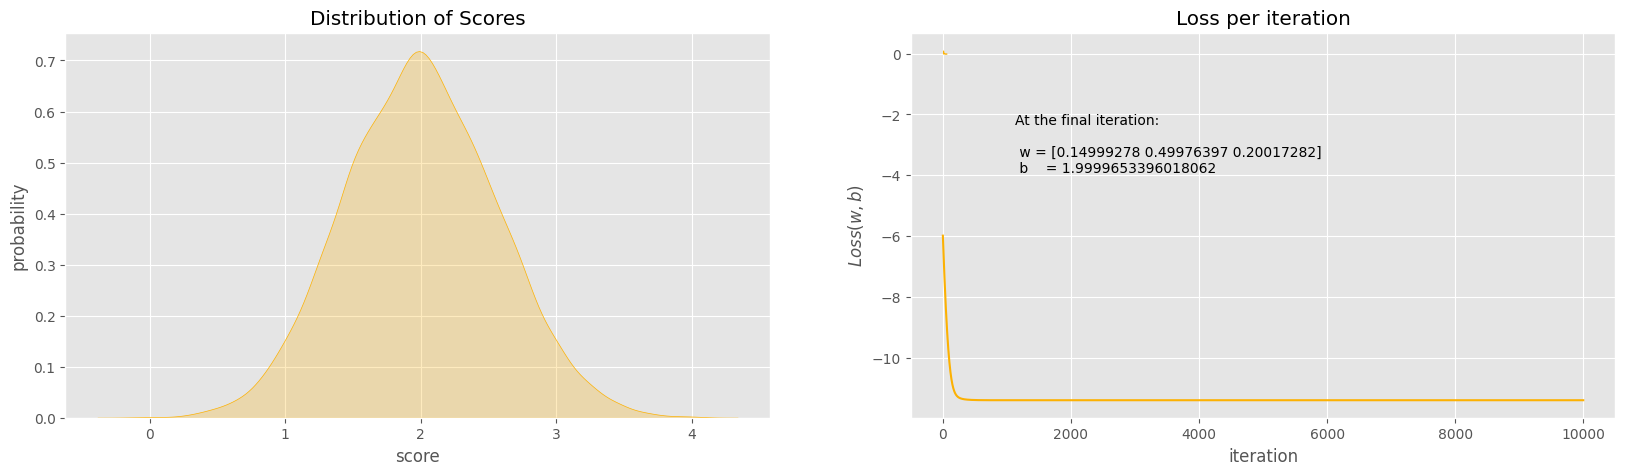

The final values for w = [0.14999278 0.49976397 0.20017282]
The final value for b = 1.9999653396018062


In [178]:
%reset -f
# source code adapted from https://github.com/ximenasandoval/
#                          Poisson_regression/blob/main/
#                          Poisson%20regression%20model.ipynb

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import normal
plt.rcParams['figure.figsize'] = (16,8)
plt.style.use('ggplot')



np.random.seed(37)
sns.color_palette("Set2", as_cmap=True)

M = 10_000
x = np.hstack([
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1)
])
z = np.dot(x, np.array([0.15, 0.5, 0.2])) + 2.0 + normal(0.0, 0.01, M)
y = np.exp(z)



fig, ax = plt.subplots(1, 2, figsize=(20, 5))

sns.kdeplot(z, ax=ax[0], color='#fcb103', fill=True)
ax[0].set_title(r'Distribution of Scores')
ax[0].set_xlabel('score')
ax[0].set_ylabel('probability')

sns.kdeplot(y, ax=ax[1], color='#fcb103', fill=True)
ax[1].set_title(r'Distribution of Means')
ax[1].set_xlabel('mean')
ax[1].set_ylabel('probability')

def loss(x, y, w, b):
    y_hat = np.exp(x @ w + b)
    # You can use the normal MSE error too! 
    #error = np.square(y_hat - y).mean() / 2
    error = (y_hat - np.log(y_hat) * y).mean()
    return error
        
def grad(x, y, w, b):
    M, n = x.shape
    y_hat = np.exp(x @ w + b)
    dw = (x.T @ (y_hat - y)) / M
    db = (y_hat - y).mean()
    return dw, db

def gradient_descent(x, y, w_0, b_0, alpha, num_iter):
    w, b = w_0.copy(), b_0
    hist = np.zeros(num_iter)
    M, n = x.shape
    
    for iter in range(num_iter):
        dw, db = grad(x, y, w, b)
        w -= alpha * dw 
        b -= alpha * db
        hist[iter] = loss(x, y, w, b)

    return w, b, hist


M, n = x.shape
w_0 = np.zeros((n, ))
b_0 = 1
alpha = 0.001
w, b, hist = gradient_descent(x, y, w_0, b_0, alpha, num_iter=10_000)




plt.plot(hist, 'b', color='#fcb103')
plt.title(u'Loss per iteration')
plt.xlabel(u'iteration')
plt.ylabel(r'$Loss(w, b)$')
plt.figtext(x=.6, y=.6, s="At the final iteration:\n\n w = {}\n b    = {}".format(w, b))
plt.show()



print(f"The final values for w = {w}")
print(f"The final value for b = {b}")



# 7.8 Pipe Burst Count/Prediction

:::{warning}
This example uses a simulated dataset.
:::

Modeling the number of pipe burst incidents as a function of pipe age and urban location.

Simulated Dataset Overview:

|Variable	|Description|
|-----------|-----------|
|Pipe_Age	|Age of the pipeline in years|
|Urban	|1 if pipe is in urban area, 0 otherwise|
|Incidents	|Number of burst incidents (count)|

In [201]:
%reset -f
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Simulate dataset
np.random.seed(42)
n = 100
Pipe_Age = np.random.uniform(0, 10, n)
Urban = np.random.binomial(1, 0.5, n)
X = sm.add_constant(pd.DataFrame({'Pipe_Age': Pipe_Age, 'Urban': Urban}))

beta_true = np.array([0.5, 0.2, 0.8])  # intercept, age effect, urban effect
mu = np.exp(X @ beta_true)
Incidents = np.random.poisson(mu)

df_sim = pd.DataFrame({'Pipe_Age': Pipe_Age, 'Urban': Urban, 'Incidents': Incidents})

In [206]:
X.describe()

,const,Pipe_Age,Urban
count,100.0,100.000000,100.000000
mean,1.0,4.701807,0.510000
std,0.0,2.974894,0.502418
min,1.0,0.055221,0.000000
25%,1.0,1.932008,0.000000
50%,1.0,4.641425,1.000000
75%,1.0,7.302031,1.000000
max,1.0,9.868869,1.000000


In [207]:
# Fit and summarize Poisson model
poisson_model = sm.GLM(df_sim.Incidents, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Incidents   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -233.32
Date:                Thu, 03 Jul 2025   Deviance:                       107.99
Time:                        19:20:49   Pearson chi2:                     103.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9805
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4602      0.104      4.404      0.0

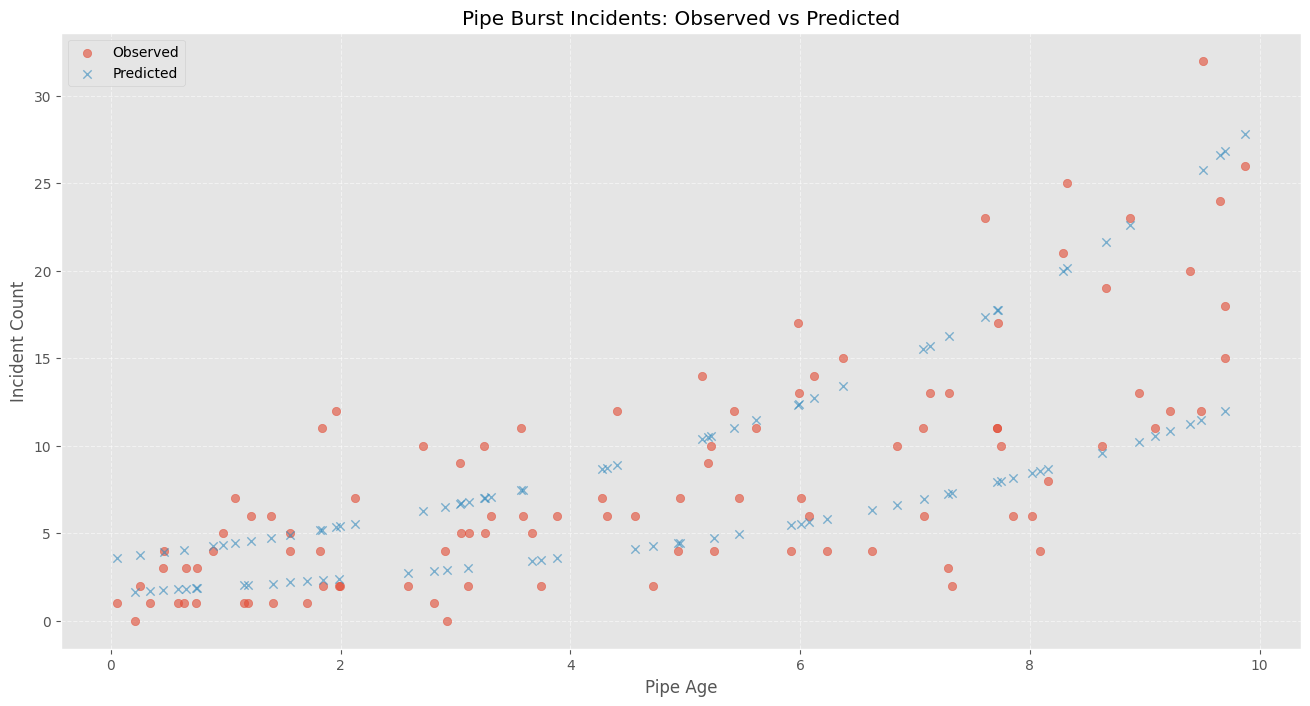

In [208]:
# Plot observed vs predicted
df_sim['Predicted'] = poisson_model.predict(X)
plt.scatter(df_sim.Pipe_Age, df_sim.Incidents, label='Observed', alpha=0.6)
plt.scatter(df_sim.Pipe_Age, df_sim.Predicted, marker='x', label='Predicted', linewidth=1, alpha=0.6)
plt.xlabel('Pipe Age')
plt.ylabel('Incident Count')
plt.legend()
plt.title('Pipe Burst Incidents: Observed vs Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

:::{tip} Generalized Linear Models (GLM) Toolbox

Many real-world engineering problems involve data that aren't well-modeled by ordinary linear regression — such as binary outcomes, event counts, or skewed continuous responses. Generalized Linear Models (GLMs) provide a unified framework to handle these cases.

#### GLM Structure:
A GLM consists of three components:
1. **Random Component**: The distribution of the response variable (e.g., Binomial, Poisson, Gamma).
2. **Systematic Component**: The linear predictor:  
   $$
   \eta_i = X_i \cdot \beta
   $$
3. **Link Function**: Connects the expected value to the linear predictor:  
   $$
   g(\mu_i) = \eta_i
   $$

#### Common Link Functions:
| Model Type              | Distribution | Link Function$ g(\mu)$     | Use Case                         |
|------------------------|--------------|--------------------------------|----------------------------------|
| **Logistic Regression**| Binomial     |$ \log\left(\frac{\mu}{1 - \mu}\right)$ | Binary classification           |
| **Poisson Regression** | Poisson      |$ \log(\mu)$                 | Count data (events, rates)       |
| **Gamma Regression**   | Gamma        |$ \log(\mu)$ or$ 1/\mu$  | Skewed continuous data           |

#### Interpretation Tip:
- The **log link** (used in Poisson models) ensures the model predicts non-negative values and interprets coefficients as multiplicative effects.
- The **logit link** (used in logistic regression) maps probabilities to the entire real line, making classification stable and interpretable.

GLMs are powerful because they extend linear modeling techniques to non-linear problems, while preserving familiar structures like design matrices and residual analysis.

:::

# 7.9 Bicycle Rental Count/Prediction


In [180]:
%reset -f
import os
import requests
import zipfile
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load dataset from UCI repo (daily counts)
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
filename = "bsd.zip"
csvname = "day.csv"
# Fallback: local copy if download fails
if not os.path.exists(filename):
    try:
        response = requests.get(url, timeout=60)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Dataset downloaded and saved as '{filename}'")
    except Exception as e:
        print(f"Could not download file. Please ensure '{filename}' is available locally.\n", e)


In [181]:

# Unzip the archive if not already unzipped
if not os.path.exists(csvname):
    try:
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall()
        print(f"Extracted '{csvname}' from archive.")
    except Exception as e:
        print("Error extracting ZIP file:", e)

In [182]:
# Load the daily bike rental data
df = pd.read_csv(csvname)
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  731
Model:                            GLM   Df Residuals:                      726
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0111e+05
Date:                Thu, 03 Jul 2025   Deviance:                   3.9482e+05
Time:                        18:34:37   Pearson chi2:                 3.83e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9579      0.003   2588.870      0.0

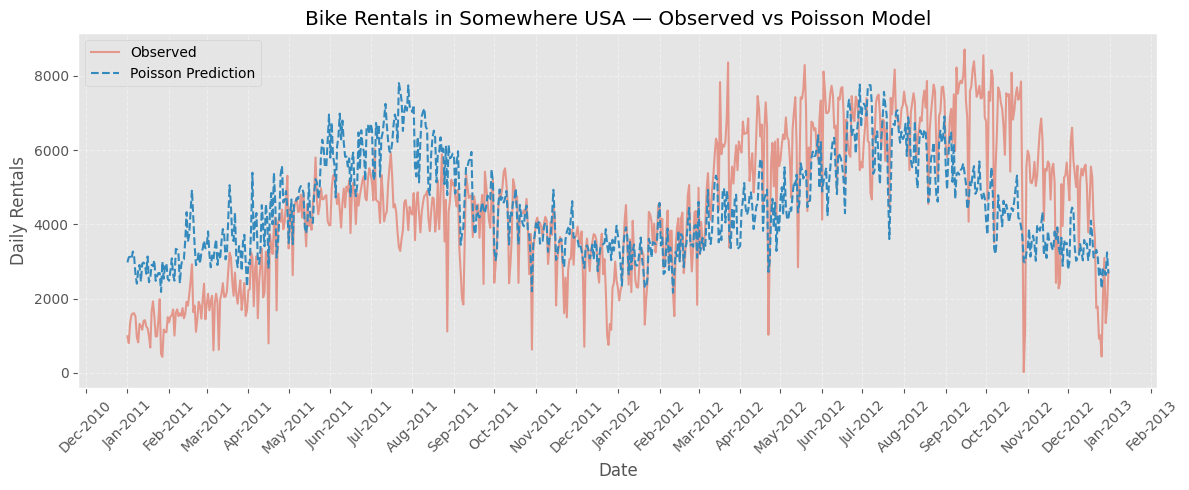

In [183]:
# Variables:
# dteday: date
# temp: normalized temperature
# hum: humidity
# weathersit: weather condition
# workingday: 1 if working day, 0 otherwise
# cnt: count of total rentals

# Create copy and select relevant columns
df_small = df[['dteday', 'cnt', 'temp', 'hum', 'workingday', 'weathersit']].copy()
df_small['const'] = 1  # manually add intercept

# Fit Poisson model
X = df_small[['const', 'temp', 'hum', 'workingday', 'weathersit']]
y = df_small['cnt']

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
# Later: Assign predicted values safely

print(poisson_model.summary())

import matplotlib.dates as mdates

df_small['Predicted'] = poisson_model.predict(X)

# Ensure dteday is datetime type
df_small['dteday'] = pd.to_datetime(df_small['dteday'])

plt.figure(figsize=(12, 5))
plt.plot(df_small['dteday'], df_small['cnt'], label='Observed', alpha=0.5)
plt.plot(df_small['dteday'], df_small['Predicted'], '--', label='Poisson Prediction')

# Set monthly ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Format as Jan-2011

plt.xlabel('Date')
plt.ylabel('Daily Rentals')
plt.title('Bike Rentals in Somewhere USA — Observed vs Poisson Model')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


Here's how to compute and visualize deviance residuals and Pearson residuals, both of which are commonly used for Poisson models:

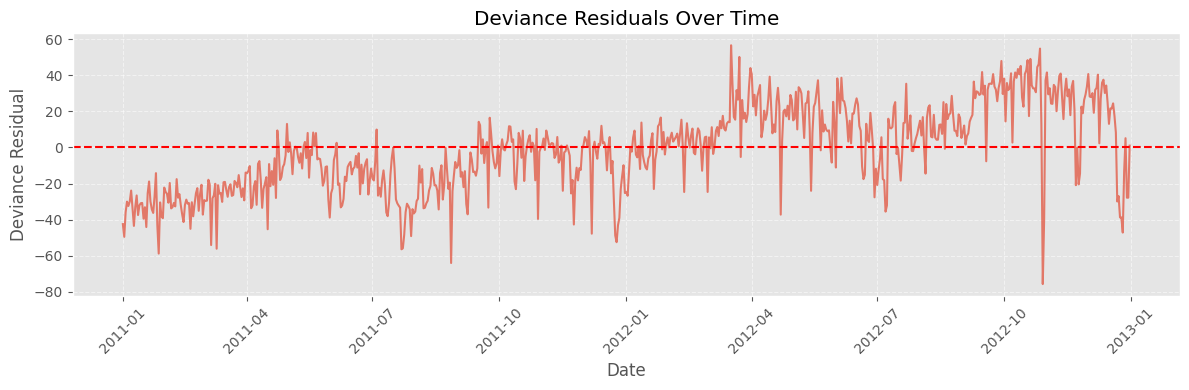

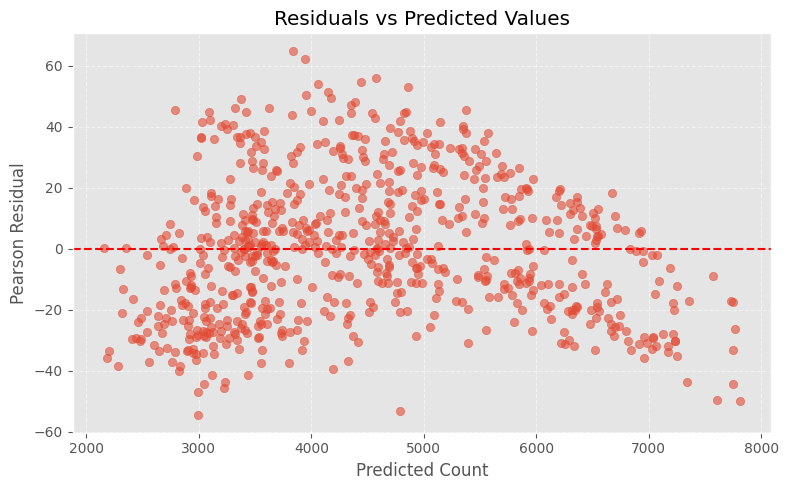

In [184]:
import numpy as np

# Calculate residuals
mu = df_small['Predicted']
y = df_small['cnt']

# Deviance residuals
deviance_resid = np.sign(y - mu) * np.sqrt(2 * (y * np.log((y + 1e-8) / mu) - (y - mu)))

# Pearson residuals
pearson_resid = (y - mu) / np.sqrt(mu)

# Add to DataFrame
df_small['Deviance_Resid'] = deviance_resid
df_small['Pearson_Resid'] = pearson_resid

# Plot: Deviance residuals over time
plt.figure(figsize=(12, 4))
plt.plot(df_small['dteday'], df_small['Deviance_Resid'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Deviance Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Deviance Residual')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot: Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(mu, pearson_resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Count')
plt.ylabel('Pearson Residual')
plt.title('Residuals vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## What to Look For:

- Deviance residuals: Large outliers may signal poor model fit or unaccounted variability.
- Pearson residuals vs predicted: Fan-shaped patterns suggest overdispersion (⇒ Negative Binomial).

## Residual Diagnostics Checklist

After fitting a Poisson regression model, use this checklist to evaluate how well the model fits the data and whether underlying assumptions are violated.

---

### 1. **Deviance Residuals**
- Plot residuals over time or index:
  - Look for **systematic patterns** or **outliers**.
  - A good fit should have residuals randomly scattered around zero.
- If many residuals are very large (in absolute value), it may suggest:
  - Overdispersion
  - Unaccounted predictors
  - Non-Poisson data generation

---

### 2. **Pearson Residuals vs. Predicted Values**
- Plot residuals against fitted values:
  - Check for **heteroskedasticity** (e.g., funnel or fan shape).
  - Residuals should be center



## Summary: Logistic and Poisson Regression in Engineering Contexts

### 1. Binary Classification with Logistic Regression
In this lesson, we introduced logistic regression as a statistical modeling technique used to classify observations into two categories (e.g., success/failure, pass/fail, event/no event). The method is particularly effective when the outcome is binary and we wish to estimate the probability that a given observation falls into one class based on one or more input features.

We explored:

- Simple logistic regression: using a single predictor.
- Multiple logistic regression: extending the model to include multiple predictors.

Interpretation: understanding model coefficients in terms of odds ratios and assessing how changes in inputs affect the likelihood of a particular outcome.

This model is useful in both directions:

- Forward prediction: Estimate the probability of a particular outcome given known inputs.
- Inverse inquiry: Determine what input values are associated with a desired probability threshold.

Example: What temperature yields a 75% chance of system failure?
This is conceptually similar to exceedance probabilities familiar from hydrologic frequency analysis.

### 2. Modeling Count Data with Poisson Regression

We also introduced Poisson regression, a related but distinct modeling tool used when the outcome is not binary, but rather a count—i.e., the number of times an event occurs.

Poisson regression is appropriate when:

- The response variable is a non-negative integer (0, 1, 2, ...).

- We can assume that the mean count increases or decreases exponentially with the input variables.

This model allows us to predict discrete quantities such as:

- Number of pipe bursts per year,
- Number of traffic accidents per day,
- Number of service calls per region.

We discussed how the log link function ensures predicted counts remain non-negative and scale multiplicatively with respect to input variables.

### 3. Model Implementation: Homebrew and Package-Based
Throughout the lesson, we demonstrated how to build both:

- Homebrew implementations of logistic and Poisson models, useful for understanding the mathematics behind the methods.

- Package-based implementations using statsmodels, scikit-learn, and other libraries, useful for practical, robust, and scalable model fitting.

We incorporated:

- Nonlinear optimization methods (e.g., Powell’s method) to minimize residuals in a custom setting,
- Maximum likelihood estimation (MLE) for a more statistically principled and numerically stable approach, especially for Poisson regression.

### 4. Creativity and Engineering Judgment
Ultimately, these regression techniques are tools—mathematical hammers in our engineering toolbox. Their power lies in how creatively and appropriately we apply them to real-world problems. Whether predicting failure risk, analyzing safety incidents, or designing smarter infrastructure systems, these models can guide both analysis and decision-making in uncertainty.

As with all tools, we emphasized the importance of:
- Residual diagnostics to check model assumptions,
- Interpretable results to ensure engineering relevance,

And using models not as ends in themselves, but as parts of a broader cycle of observation, modeling, validation, and action.

## End of Section